# **Netflix Movies and TV Shows Clustering**

##### **Project Type** - Unsupervised ML (Clustering + Content-Based Recommendation System)
##### **Contribution** - Individual
##### **Name** - Aartika Sharan
##### **Program** - AlmaBetter Data Science and AI

# **GitHub Link** - https://github.com/aartika1177/Netflix-Movies-and-TV-Shows-Clustering.git

# **Project Summary**

**The problem** - Netflix has a huge number of movies and TV shows, so it can sometimes be difficult for viewers to decide what to watch. In this project, I used unsupervised machine learning to group similar Netflix titles together and then used those similarities to build a recommendation system. The recommender suggests 10 titles that are similar to a movie or TV show selected by the user. The idea is to make it easier to explore the catalogue and discover content that matches a viewer's interests.

**The data** - I worked with a Netflix titles dataset containing 7,787 titles and 12 columns, including type, title, director, cast, country, date added, release year, rating, duration, genres and description. The dataset was collected from Flixable, a third-party Netflix search website. There were no duplicate records. Some columns had a significant number of missing values, especially director (31%), cast (9%) and country (6.5%). Instead of trying to guess the missing information, I replaced these values with blank text. I also removed 17 rows where important information such as rating or date was missing. This left 7,770 titles, with approximately 69% movies and 31% TV shows. One interesting observation was that a director was listed for around 97% of movies but only 7.7% of TV shows, so director information by itself was not a strong enough feature for clustering.

**Exploration** - I created 15 visualisations, including univariate, bivariate and multivariate charts, to understand the dataset and find useful patterns. Some of the main observations were that International Movies, Dramas and Comedies were among the largest genres. Movie additions were highest in 2019, while TV show additions peaked in 2020. TV shows were generally added closer to their original release: around 67.5% were added within one year of release compared with 50.3% of movies. Kids' content made up about 17.6% of TV shows and 6.8% of movies. I also found that kids' movies had a median duration of around 69 minutes. South Korea and Japan had a higher proportion of TV content, while India's catalogue contained a larger share of movies.

I also performed three hypothesis tests to check some of these observations statistically. The results showed that newer movies were shorter on average (96 minutes compared with 113 minutes) and that TV shows had a higher share of kids' content. The month in which a title was added was not significantly related to whether it was a movie or TV show (p ≈ 0.14).

**Preparation** - To prepare the data for machine learning, I combined the description, genres, rating, cast, country and director of each title into one text field. I converted names into single tokens so that, for example, "Shah Rukh Khan" could be treated as shah_rukh_khan. The text was then converted to lowercase, cleaned and stripped of stopwords. After that, I used TF-IDF to convert the text into 10,000 numerical features. Since this created a high-dimensional dataset, I used TruncatedSVD to reduce it to 50 components. I tested different numbers of components, from 10 to 300, before selecting the final representation based on clustering and recommendation performance.

**Models**.- I compared three clustering algorithms: K-Means, Agglomerative Clustering and Gaussian Mixture Model (GMM). I used 5-fold cross-validation to choose the number of clusters for K-Means (3-fold for GMM) and tuned the main settings of each model. The final models were built using 10 clusters.

The tuned K-Means model gave the strongest results in my experiments. Its silhouette score improved from around 0.04 in the initial model to around 0.11, while the Davies-Bouldin score decreased from around 4.8 to around 2.8. The largest cluster contained about 18% of the titles. The silhouette score on unseen data was also very close to the training score, which suggests that the clustering pattern was reasonably stable.

Agglomerative Clustering placed around 42% of the titles into one large cluster, while GMM produced weaker separation between the clusters. After looking at the titles in the different K-Means clusters, I could identify groups such as Kids TV, Stand-Up Comedy, Documentaries, Docuseries, International TV Shows, Action and Sci-Fi, Children and Family Movies, as well as different drama and comedy groups.

I also used a surrogate logistic regression model to check whether the words in the dataset could explain the assigned clusters. It achieved around 97% accuracy, which suggests that the clusters were based on meaningful and identifiable patterns in the text features.

**Recommender and deployment** - After building the clusters, I created a content-based recommendation system using cosine similarity. The system compares the features of a selected title with the other titles and returns the 10 most similar ones.

For example, when I tested Naruto, the system returned other anime-related titles such as InuYasha and Bleach. When I tested Our Planet, the recommendations were mainly nature and documentary titles. The recommended titles shared around 73% of their genres with the selected title, compared with around 9% for randomly selected titles.

The TF-IDF vectoriser, SVD model and K-Means model were saved using Joblib. I then loaded the saved models again and tested them with a new title to make sure they could work with previously unseen data. I also wrote a simple Streamlit script (app.py) that lets a user select a title and see recommendations. In this notebook, the recommender is demonstrated directly.

**Limitations** - There are a few limitations to this project. The silhouette scores are relatively low, which is not unusual when working with text data. A title can also fit into more than one theme, while a clustering algorithm assigns it to a single cluster. The dataset only contains information up to early 2021, so it does not represent the current Netflix catalogue. Also, the recommendation system is based only on content similarity and does not use user viewing history, ratings or personal preferences.

**Future work** - This project could be improved by using sentence embeddings instead of traditional TF-IDF features, incorporating user behaviour, combining content-based and collaborative filtering, hosting the Streamlit application online and deploying the model through an Azure ML endpoint.

# **Problem Statement**

Netflix has thousands of movies and TV shows, and having so many options can make it difficult for viewers to decide what to watch. A recommendation system can help by finding titles that are similar to something the viewer already likes.

Why this matters: If viewers cannot find something to watch, they may stop using the service. Clusters can be used to build themed browse rows, "because you watched" suggestions, and to find gaps in the catalogue, such as too little kids' content. Machine learning suits this problem because grouping 7,770 titles by hand is not realistic, and genres alone do not capture the story, cast or country.

In this project, the aim is to use the information available about Netflix titles to identify groups of similar movies and TV shows. These groups can help us understand the different types of content in the catalogue and can also be used as a foundation for making recommendations.

The project focuses on three main objectives:

Group similar Netflix titles into meaningful clusters.
Compare different clustering algorithms and evaluate which one works better on this dataset.
Recommend 10 similar titles when a user selects a movie or TV show.
Goal

The main goal is to create clusters where titles within the same group have similar content characteristics, while titles in different groups are less similar. The same content information is then used to build a recommendation system based on cosine similarity.

Why Unsupervised Learning?

This is an unsupervised learning problem because there is no target column telling the model which cluster each title belongs to. Instead, the model has to look at the available information and find patterns and similarities on its own.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries


In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import normalize
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42

### Dataset Loading


In [ ]:

DATA_PATH = 'NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv'
df = pd.read_csv(DATA_PATH)

### Dataset First View


In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


### Dataset Rows & Columns count


In [ ]:
print('Number of rows   :', df.shape[0])
print('Number of columns:', df.shape[1])

Number of rows   : 7787
Number of columns: 12


### Dataset Information


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


#### Duplicate Values


In [ ]:
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate titles:', df['title'].duplicated().sum())

Duplicate rows: 0
Duplicate titles: 0


#### Missing Values/Null Values


In [ ]:
missing = pd.DataFrame({'count': df.isna().sum(), 'percent': (df.isna().mean() * 100).round(2)})
missing[missing['count'] > 0]

,count,percent
director,2389,30.68
cast,718,9.22
country,507,6.51
date_added,10,0.13
rating,7,0.09


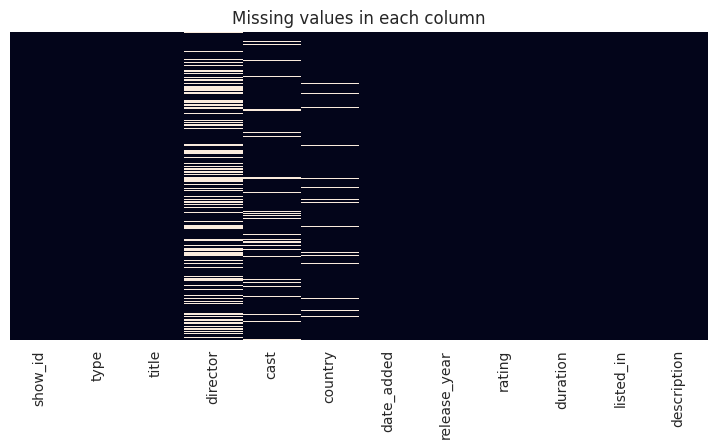

In [ ]:
# Visualizing the missing values (light lines = missing)
plt.figure(figsize=(9, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing values in each column')
plt.show()

### What did you know about your dataset?

- The dataset has **7,787 titles and 12 columns**. Every column is text except `release_year`.
- There are **no duplicate rows** and no duplicate titles.
- Missing values: `director` ~31%, `cast` ~9%, `country` ~6.5%. `date_added` (10 rows) and `rating` (7 rows) have very few gaps.
- The data comes from Flixable, a third-party Netflix search site. Titles were added to Netflix between 2008 and early 2021.

## ***2. Understanding Your Variables***


In [ ]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [ ]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,7787,7787,s7787,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,7787,2,Movie,5377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,7787,7787,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,5398,4049,"Raúl Campos, Jan Suter",18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7069,6831,David Attenborough,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7280,681,United States,2555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,7777,1565,"January 1, 2020",118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,7787.0,NaN,NaN,NaN,2013.93258,8.757395,1925.0,2013.0,2017.0,2018.0,2021.0
rating,7780,14,TV-MA,2863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,7787,216,1 Season,1608,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

| Column | Meaning |
|---|---|
| show_id | Unique ID of the title |
| type | Movie or TV Show |
| title | Name of the title |
| director | Director(s), many are missing |
| cast | Actors in the title |
| country | Country(ies) that produced it |
| date_added | Date Netflix added it |
| release_year | Year it was originally released |
| rating | Age rating (TV-MA, PG, ...) |
| duration | Minutes for a movie, number of seasons for a TV show |
| listed_in | Genres (one or more) |
| description | Short summary of the title |


### Check Unique Values for each variable.


In [ ]:
df.nunique()

,0
show_id,7787
type,2
title,7787
director,4049
cast,6831
country,681
date_added,1565
release_year,73
rating,14
duration,216


## ***3. Data Wrangling***

### Data Wrangling Code


In [ ]:
# 1. Text columns: a missing director / cast / country just means "unknown", so use an empty string.
df[['director', 'cast', 'country']] = df[['director', 'cast', 'country']].fillna('')

# 2. rating and date_added: only 17 rows are missing, so it is safe to drop them.
df = df.dropna(subset=['rating', 'date_added']).reset_index(drop=True)   # reset_index keeps row numbers 0..n-1

print('Shape after cleaning:', df.shape)
print('Missing values left :', df.isna().sum().sum())

Shape after cleaning: (7770, 12)
Missing values left : 0


In [ ]:
# 3. Helper columns (used for charts and hypothesis tests)
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# first listed country is treated as the "main" country
df['main_country'] = df['country'].str.split(',').str[0].replace('', 'Unknown')

# duration: "90 min" for movies, "2 Seasons" for TV shows -> keep the number
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(int)

# how many years passed between release and arrival on Netflix
df['gap_years'] = df['year_added'] - df['release_year']

# group the 14 rating labels into 5 easy audience groups
audience_map = {'TV-MA': 'Mature', 'R': 'Mature', 'NC-17': 'Mature',
                'TV-14': 'Teen', 'PG-13': 'Teen',
                'TV-PG': 'Older kids', 'PG': 'Older kids',
                'TV-Y7': 'Kids', 'TV-Y7-FV': 'Kids', 'TV-Y': 'Kids', 'TV-G': 'Kids', 'G': 'Kids'}
df['audience'] = df['rating'].map(audience_map).fillna('Other')

df[['type', 'duration', 'duration_num', 'year_added', 'month_added', 'main_country', 'gap_years', 'audience']].head()

,type,duration,duration_num,year_added,month_added,main_country,gap_years,audience
0,TV Show,4 Seasons,4,2020,August,Brazil,0,Mature
1,Movie,93 min,93,2016,December,Mexico,0,Mature
2,Movie,78 min,78,2018,December,Singapore,7,Mature
3,Movie,80 min,80,2017,November,United States,8,Teen
4,Movie,123 min,123,2020,January,United States,12,Teen


### What all manipulations have you done and insights you found?

- Filled missing `director`, `cast`, `country` with an empty string. We cannot guess a director, and dropping 30% of rows would lose a lot of data.
- Dropped 17 rows with a missing `rating` or `date_added`. Final data: **7,770 titles**.
- Created `year_added`, `month_added`, `main_country`, `duration_num`, `gap_years` and `audience`.
- **Insight:** the director is known for 97% of movies but only **7.7% of TV shows**. So "missing director" is mostly a TV show feature, not random. That is why director alone is a weak clustering signal.

## ***4. Data Visualization, Storytelling & Experimenting with charts***

We follow the **UBM rule**: **U**nivariate (one variable), **B**ivariate (two variables), **M**ultivariate (three or more). 15 charts in total: 6 univariate (1-6), 6 bivariate (7-12) and 3 multivariate (13-15).

---
# U - Univariate Analysis


#### Chart - 1 : Movies vs TV Shows


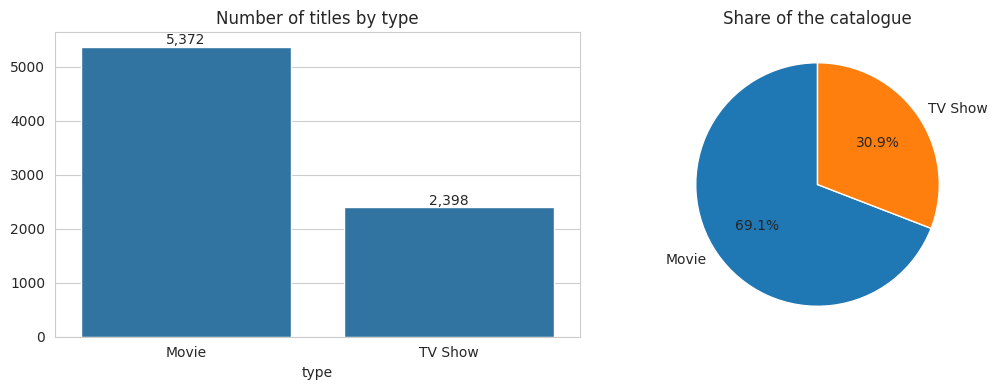

In [ ]:
counts = df['type'].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax[0])
ax[0].set_title('Number of titles by type')
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 50, f'{v:,}', ha='center')
ax[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Share of the catalogue')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A bar chart plus a pie chart is the simplest way to see how a single category splits.

##### 2. What is/are the insight(s) found from the chart?
Movies make up **69.1%** (5,372 titles) and TV shows **30.9%** (2,398 titles) of the catalogue.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** a big movie library suits one-time viewers. **Negative risk:** TV shows keep people subscribed for longer (many episodes), so a smaller TV share can mean less stickiness. This supports investing in series.


#### Chart - 2 : Top 12 genres


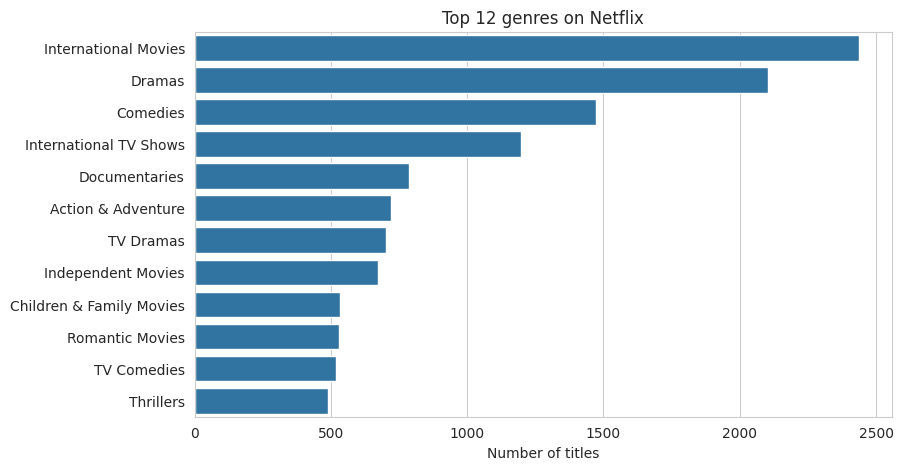

Distinct genres: 42


In [ ]:
genres = df['listed_in'].str.split(', ').explode()       # one row per title-genre pair
top_genres = genres.value_counts().head(12)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title('Top 12 genres on Netflix'); plt.xlabel('Number of titles'); plt.ylabel('')
plt.show()
print('Distinct genres:', genres.nunique())

##### 1. Why did you pick the specific chart?
A title can have several genres, so we split them and count each one. A horizontal bar chart keeps long genre names readable.

##### 2. What is/are the insight(s) found from the chart?
**International Movies (2,437), Dramas (2,105) and Comedies (1,471)** lead, followed by International TV Shows (1,197) and Documentaries (786).

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** it shows where the library is deep. **Negative risk:** niche genres (Classic & Cult TV, Stand-Up, Sports) are small. They could be an opportunity if there is demand, or dead weight if there is not.


#### Chart - 3 : Movie length


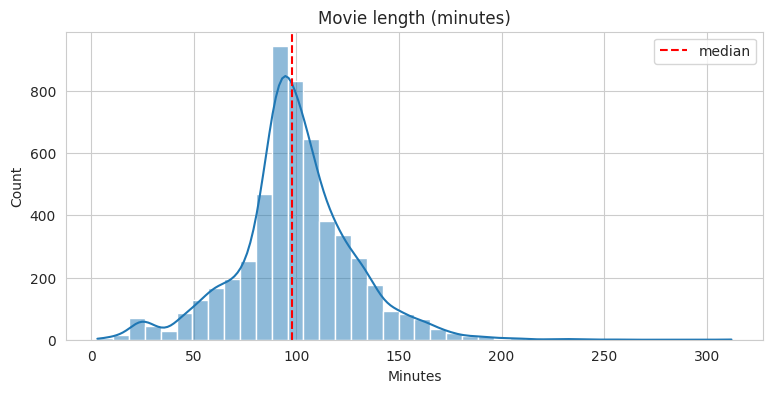

count    5372.0
mean       99.3
std        28.5
min         3.0
25%        86.0
50%        98.0
75%       114.0
max       312.0
Name: duration_num, dtype: float64


In [ ]:
movies = df[df['type'] == 'Movie']
plt.figure(figsize=(9, 4))
sns.histplot(movies['duration_num'], bins=40, kde=True)
plt.axvline(movies['duration_num'].median(), color='red', linestyle='--', label='median')
plt.title('Movie length (minutes)'); plt.xlabel('Minutes'); plt.legend()
plt.show()
print(movies['duration_num'].describe().round(1))

##### 1. Why did you pick the specific chart?
A histogram shows the shape of one numerical variable. The red line marks the median.

##### 2. What is/are the insight(s) found from the chart?
The median movie is **98 minutes** and the middle half lies between **86 and 114 minutes**. There is a right tail up to 312 minutes (336 movies fall outside the usual 44-156 minute range).

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** consistent length helps viewers plan their evening. **Negative risk:** very short (under 45 min) and very long titles are often specials or documentaries and may need separate labelling so they do not disappoint viewers.


#### Chart - 4 : Content ratings


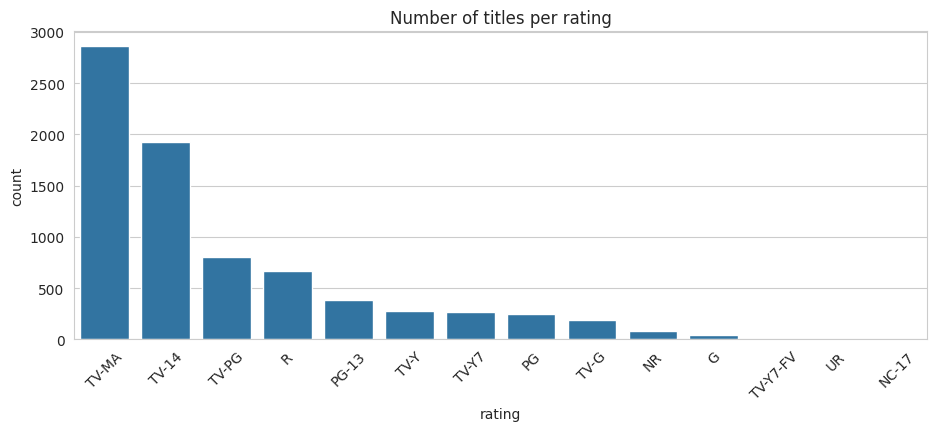

In [ ]:
order = df['rating'].value_counts().index
plt.figure(figsize=(11, 4))
sns.countplot(data=df, x='rating', order=order)
plt.xticks(rotation=45); plt.title('Number of titles per rating')
plt.show()

##### 1. Why did you pick the specific chart?
A count plot shows how many titles each rating has, sorted from most to least.

##### 2. What is/are the insight(s) found from the chart?
**TV-MA (2,861) and TV-14 (1,928)** dominate. Kids' ratings such as TV-Y and TV-G are small.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** strong for adult and teen viewers. **Negative risk:** a thin kids library may limit family plans, so households with children may prefer other services.


#### Chart - 5 : Top directors


director
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Name: count, dtype: int64


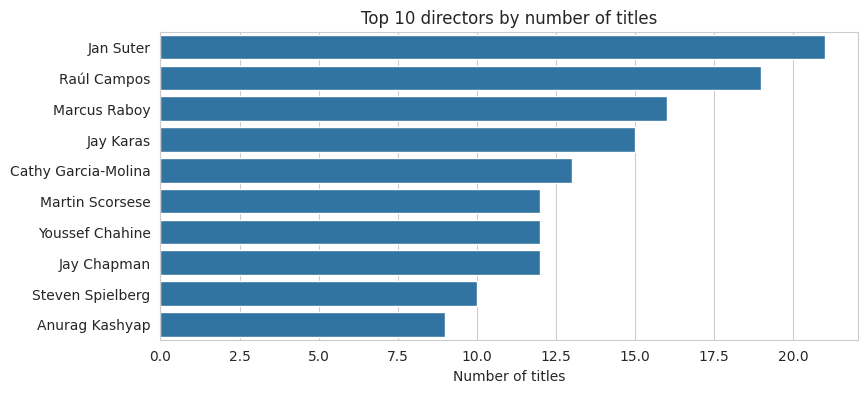

Jan Suter: 21 titles, most common genre = Stand-Up Comedy
Raúl Campos: 19 titles, most common genre = Stand-Up Comedy
Marcus Raboy: 16 titles, most common genre = Stand-Up Comedy
Jay Karas: 15 titles, most common genre = Stand-Up Comedy
Cathy Garcia-Molina: 13 titles, most common genre = International Movies

Share of TV shows with a known director: 7.7%
Share of movies   with a known director: 97.0%


In [ ]:
directors = df['director'].replace('', np.nan).dropna().str.split(', ').explode()
top_dir = directors.value_counts().head(10)
print(top_dir.head(5))

plt.figure(figsize=(9, 4))
sns.barplot(x=top_dir.values, y=top_dir.index)
plt.title('Top 10 directors by number of titles'); plt.xlabel('Number of titles'); plt.ylabel('')
plt.show()

# what do the top 5 directors usually make?
for name in top_dir.index[:5]:
    their = df[df['director'].str.split(', ').apply(lambda names: name in names)]
    print(f"{name}: {len(their)} titles, most common genre = {their['listed_in'].str.split(', ').explode().value_counts().index[0]}")
print()
print('Share of TV shows with a known director: %.1f%%' % ((df[df.type == 'TV Show']['director'] != '').mean() * 100))
print('Share of movies   with a known director: %.1f%%' % ((df[df.type == 'Movie']['director'] != '').mean() * 100))

##### 1. Why did you pick the specific chart?
A bar chart of the top names shows who is most frequent. We also print the main genre of each top director to understand why they appear so often.

##### 2. What is/are the insight(s) found from the chart?
No director has more than 21 titles: Jan Suter (21), Raul Campos (19), Marcus Raboy (16), Jay Karas (15). The printed genres show what they mostly make. Also, only **7.7% of TV shows have a director** compared with 97% of movies.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** repeat directors are reliable partners for recurring content such as specials. **Negative risk:** because director data is almost empty for TV shows, a director-based recommender would work for movies but not for series. This is why we mix many text fields instead of using director alone.


#### Chart - 6 : Top actors


cast
Anupam Kher         42
Shah Rukh Khan      35
Naseeruddin Shah    30
Om Puri             30
Akshay Kumar        29
Name: count, dtype: int64


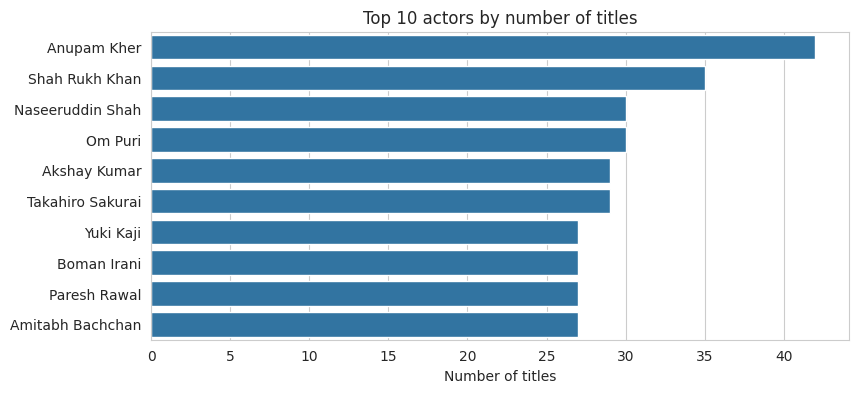

In [ ]:
actors = df['cast'].replace('', np.nan).dropna().str.split(', ').explode()
top_actors = actors.value_counts().head(10)
print(top_actors.head(5))

plt.figure(figsize=(9, 4))
sns.barplot(x=top_actors.values, y=top_actors.index)
plt.title('Top 10 actors by number of titles'); plt.xlabel('Number of titles'); plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?
A bar chart ranks actors by how often they appear.

##### 2. What is/are the insight(s) found from the chart?
**Anupam Kher (42), Shah Rukh Khan (35), Naseeruddin Shah (30) and Om Puri (30)** appear most, so Indian cinema dominates the top. Takahiro Sakurai (29) is a Japanese voice actor, showing the strong anime presence.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** familiar faces help recommendations (people who liked one Shah Rukh Khan film may like another). **Negative risk:** the top actors are concentrated in two regions, so cast-based recommendations will favour Indian and Japanese content.


---
# B - Bivariate Analysis


#### Chart - 7 : Titles added per year by type (numerical x categorical)


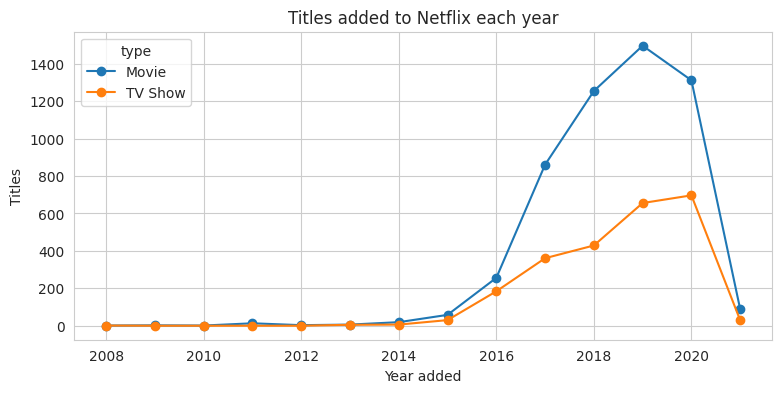

type,Movie,TV Show
year_added,,
2014,19,6
2015,58,30
2016,256,184
2017,861,361
2018,1255,429
2019,1497,656
2020,1312,697
2021,88,29


In [ ]:
added = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
added.plot(figsize=(9, 4), marker='o')
plt.title('Titles added to Netflix each year'); plt.xlabel('Year added'); plt.ylabel('Titles')
plt.show()
added.tail(8)

##### 1. Why did you pick the specific chart?
A line chart shows change over time, with one line per type.

##### 2. What is/are the insight(s) found from the chart?
Additions grew very fast after 2015. **Movies peaked in 2019 (1,497 titles)** and **TV shows peaked in 2020 (697 titles)**. The data only covers the first weeks of 2021, so 2021 looks small (88 movies and 29 shows).

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** rapid growth in both types, and TV shows are still growing. **Negative risk:** more titles make discovery harder for viewers. That is exactly the problem clustering and recommendations solve.


#### Chart - 8 : Top 10 countries by type (categorical x categorical)


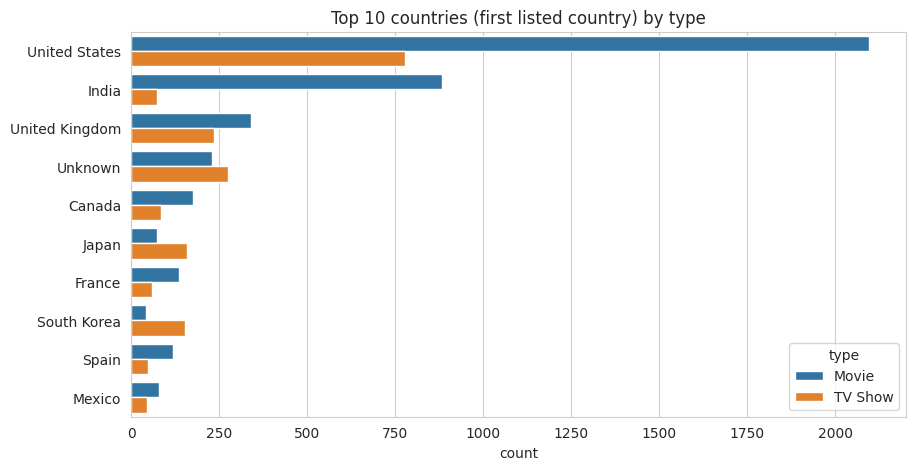

In [ ]:
top_countries = df['main_country'].value_counts().head(10).index
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['main_country'].isin(top_countries)], y='main_country', hue='type', order=top_countries)
plt.title('Top 10 countries (first listed country) by type'); plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?
A grouped bar chart compares movies and TV shows side by side for each country.

##### 2. What is/are the insight(s) found from the chart?
The **US leads** (2,097 movies, 777 shows), then India (883 movies but only 73 shows) and the UK (341 movies, 235 shows). **Japan is TV-heavy** (160 shows vs 75 movies). 'Unknown' is the fourth biggest group.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** shows where to license and invest locally. **Negative risk:** dependence on the US, and a weak Indian TV show library even though India has a huge audience.


#### Chart - 9 : Audience group by type (categorical x categorical)


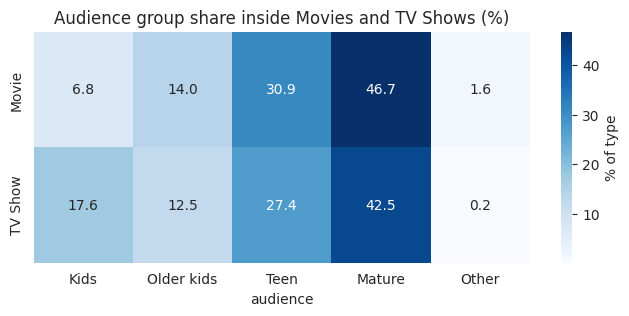

In [ ]:
share = pd.crosstab(df['type'], df['audience'], normalize='index') * 100      # % inside each type
share = share[['Kids', 'Older kids', 'Teen', 'Mature', 'Other']]

plt.figure(figsize=(8, 3))
sns.heatmap(share, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '% of type'})
plt.title('Audience group share inside Movies and TV Shows (%)'); plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?
Both variables are categories and the two types have different sizes (5,372 vs 2,398). Percentages inside each type make the comparison fair, which raw counts cannot do.

##### 2. What is/are the insight(s) found from the chart?
Mature content is the biggest group for both (47% of movies, 43% of shows). The real difference is kids' content: **17.6% of TV shows are for young children against only 6.8% of movies**.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** kids' TV series are a retention driver for families. **Negative risk:** only 6.8% of movies target young kids, so the family-movie-night segment is thin and competes with Disney+ and similar services.


#### Chart - 10 : Movie length by genre (numerical x categorical)


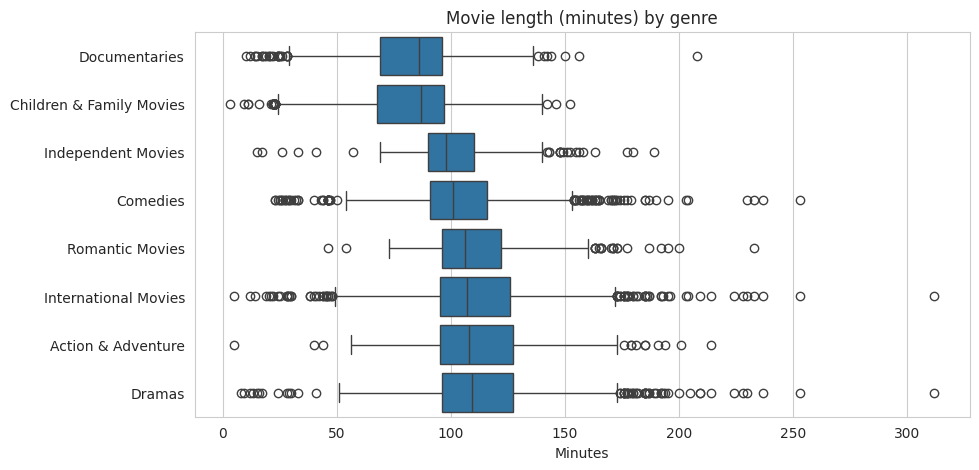

genre
Documentaries                86.0
Children & Family Movies     87.0
Independent Movies           98.0
Comedies                    101.0
Romantic Movies             106.0
International Movies        107.0
Action & Adventure          108.0
Dramas                      109.0
Name: duration_num, dtype: float64


In [ ]:
movie_genres = movies.assign(genre=movies['listed_in'].str.split(', ')).explode('genre')
top8 = movie_genres['genre'].value_counts().head(8).index
plot_data = movie_genres[movie_genres['genre'].isin(top8)]
order = plot_data.groupby('genre')['duration_num'].median().sort_values().index

plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_data, y='genre', x='duration_num', order=order)
plt.title('Movie length (minutes) by genre'); plt.xlabel('Minutes'); plt.ylabel('')
plt.show()
print(plot_data.groupby('genre')['duration_num'].median().sort_values())

##### 1. Why did you pick the specific chart?
We compare a number (minutes) across several categories. A box plot shows the median, spread and outliers for every genre in one picture.

##### 2. What is/are the insight(s) found from the chart?
**Documentaries (median 86 min) and Children & Family (87)** are shortest; **Dramas (109), Action & Adventure (108) and International Movies (107)** are longest. Every genre has a few very long outliers.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** Netflix can label rows by viewing time and use short documentaries and family films for quick viewing slots. **Negative risk:** outliers over 180 minutes may not be finished in one sitting, which can hurt completion rates.


#### Chart - 11 : Release year vs year added (numerical x numerical)


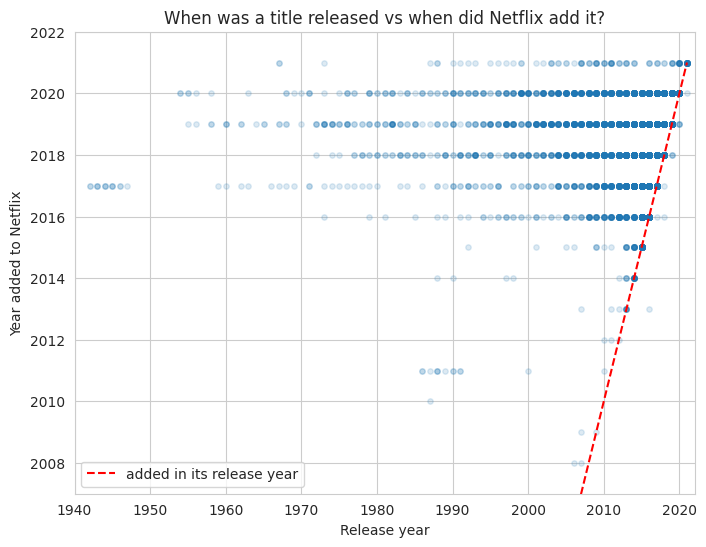

         mean  median
type                 
Movie     5.6     1.0
TV Show   2.3     0.0
Added within 1 year of release:
type
Movie      0.503
TV Show    0.675
Name: gap_years, dtype: float64


In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['release_year'], df['year_added'], alpha=0.15, s=15)
plt.plot([1940, 2021], [1940, 2021], color='red', linestyle='--', label='added in its release year')
plt.xlim(1940, 2022); plt.ylim(2007, 2022)
plt.xlabel('Release year'); plt.ylabel('Year added to Netflix'); plt.legend()
plt.title('When was a title released vs when did Netflix add it?')
plt.show()

print(df.groupby('type')['gap_years'].agg(['mean', 'median']).round(1))
print('Added within 1 year of release:')
print((df['gap_years'] <= 1).groupby(df['type']).mean().round(3))

##### 1. Why did you pick the specific chart?
A scatter plot is the standard way to see how two numbers relate. Points near the red line were added almost as soon as they were released.

##### 2. What is/are the insight(s) found from the chart?
Most points sit near the line, so Netflix mostly adds recent content. **TV shows are added faster: 67.5% within a year of release against 50.3% of movies.** Movies have an average gap of 5.6 years, TV shows 2.3 years. The horizontal bands above the line are older films added in bulk (library licensing).

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** a fresh catalogue keeps subscribers interested, and quick TV additions show Netflix competes on new series. **Negative risk:** half of the movies are older titles, which are cheaper but can feel outdated.


#### Chart - 12 : Month added by type (categorical x categorical)


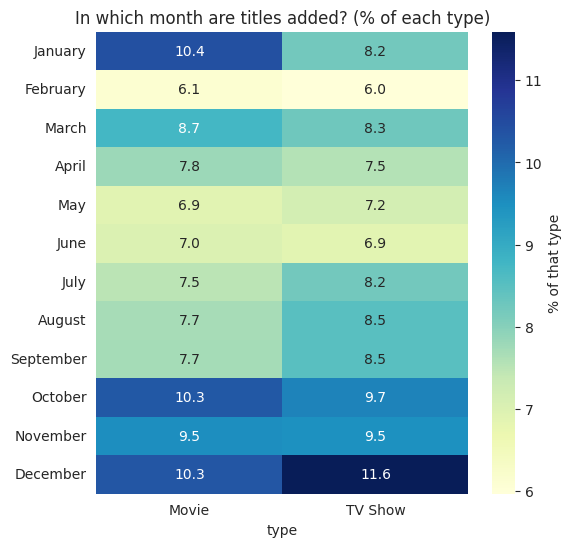

In [ ]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']
month_share = pd.crosstab(df['month_added'], df['type'], normalize='columns').reindex(month_order) * 100

plt.figure(figsize=(6, 6))
sns.heatmap(month_share, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '% of that type'})
plt.title('In which month are titles added? (% of each type)'); plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?
A heatmap of percentages shows whether the two types follow different calendars, without being fooled by their different sizes.

##### 2. What is/are the insight(s) found from the chart?
Additions are spread quite evenly (about 8-12% per month). TV shows peak in **December (11.6%)** and are lowest in **January (8.2%)**; movies are fairly flat at 9-10.5% per month. We test whether this difference is real in Hypothesis 3 below.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** steady monthly releases avoid long dry spells. **Negative risk:** none are strong here, but a December TV peak suggests holiday binge planning that could be used for marketing.


---
# M - Multivariate Analysis


#### Chart - 13 : Correlation heatmap


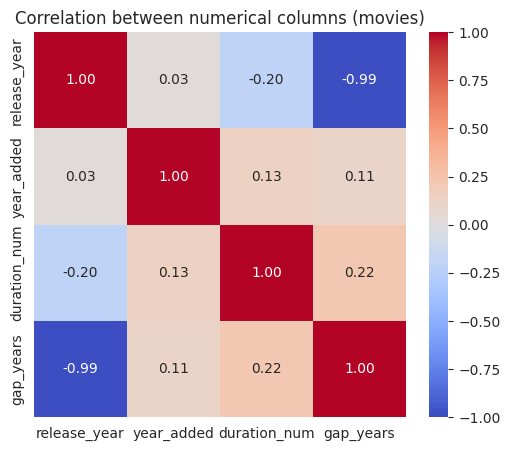

In [ ]:
num_cols = ['release_year', 'year_added', 'duration_num', 'gap_years']
corr = movies[num_cols].corr()          # movies only, because duration means minutes only for movies

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between numerical columns (movies)')
plt.show()

##### 1. Why did you pick the specific chart?
A correlation heatmap shows how every pair of numerical columns moves together, in one view.

##### 2. What is/are the insight(s) found from the chart?
`gap_years` and `release_year` are almost perfect opposites (**-0.99**) because one is calculated from the other, so we should never use both. Other links are weak: newer movies are slightly shorter (-0.20).

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** it saves us from adding duplicate features. **Negative risk:** numbers alone barely explain anything about the titles, which is why we cluster on text (genre, cast, description) instead of the numerical columns.

#### Chart - 14 : Pair plot (movies)


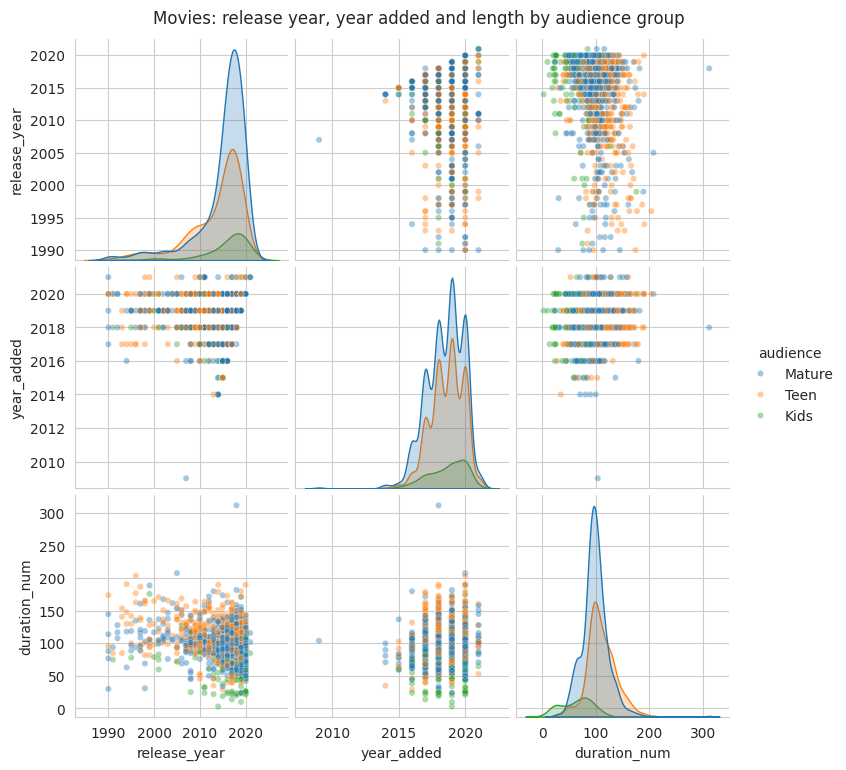

audience
Kids           69.0
Mature         97.0
Older kids     95.0
Other          93.0
Teen          106.0
Name: duration_num, dtype: float64


In [ ]:
pair_data = movies[['release_year', 'year_added', 'duration_num', 'audience']]
pair_data = pair_data[pair_data['audience'].isin(['Kids', 'Teen', 'Mature'])]
pair_data = pair_data[pair_data['release_year'] >= 1990].sample(1500, random_state=RANDOM_STATE)   # sample = faster plot

sns.pairplot(pair_data, hue='audience', diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20})
plt.suptitle('Movies: release year, year added and length by audience group', y=1.02)
plt.show()
print(movies.groupby('audience')['duration_num'].median())

##### 1. Why did you pick the specific chart?
It shows three numerical variables against each other and adds a fourth (audience group) as colour, so we see many relationships at once.

##### 2. What is/are the insight(s) found from the chart?
**Kids' movies are clearly shorter (median 69 min vs 97 for Mature and 106 for Teen).** Release year and year added have almost no link, because Netflix adds old and new films every year.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** audience and length are useful signals and suggest a 'kids and family' cluster will separate well from the rest. **Negative:** correlations are weak, so length alone cannot predict what viewers want.


#### Chart - 15 : Country x genre heatmap


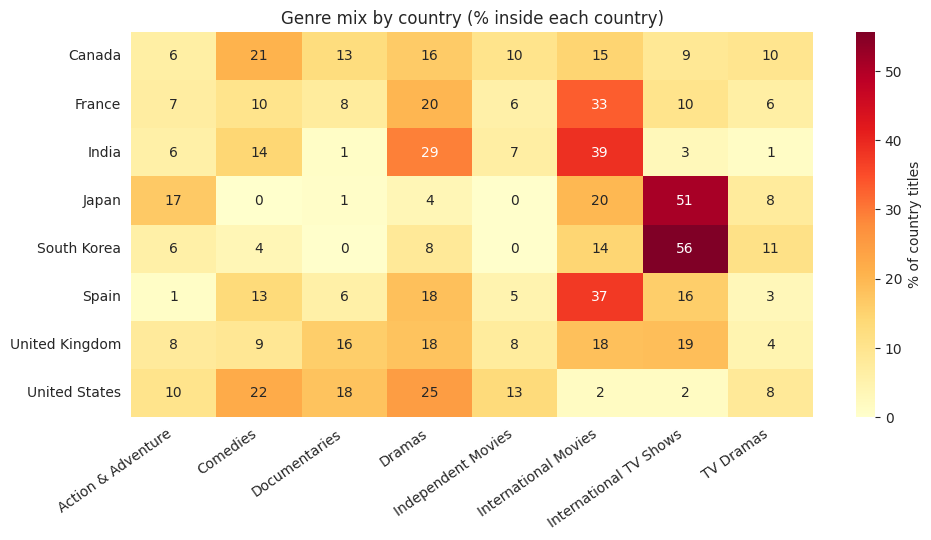

In [ ]:
known = df[df['main_country'] != 'Unknown']
top_countries = known['main_country'].value_counts().head(8).index
exploded = known.assign(genre=known['listed_in'].str.split(', ')).explode('genre').reset_index(drop=True)
top_genres = exploded['genre'].value_counts().head(8).index
subset = exploded[exploded['main_country'].isin(top_countries) & exploded['genre'].isin(top_genres)]

table = pd.crosstab(subset['main_country'], subset['genre'])
table_pct = table.div(table.sum(axis=1), axis=0) * 100          # % of each country's genre tags

plt.figure(figsize=(11, 5))
sns.heatmap(table_pct, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': '% of country titles'})
plt.title('Genre mix by country (% inside each country)')
plt.xticks(rotation=35, ha='right'); plt.ylabel(''); plt.xlabel('')
plt.show()

##### 1. Why did you pick the specific chart?
It combines three things: country, genre and the size of each share. A heatmap makes differences in genre mix easy to spot.

##### 2. What is/are the insight(s) found from the chart?
Each country has its own taste. **South Korea (56%) and Japan (51%) are mostly International TV Shows** (K-dramas and anime). **India is mostly International Movies (39%) and Dramas (29%).** The US is spread over Dramas, Comedies and Documentaries and very few US titles are tagged International. The UK is balanced across four genres (16-19% each).

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
**Positive:** clear guidance for regional licensing: series from Korea and Japan, films from India. It also shows that country and genre are informative for clustering. **Negative risk:** heavy dependence on a few countries per genre makes the catalogue vulnerable if licensing deals end.


## ***5. Hypothesis Testing***

### Based on our chart experiments, we define three statements and test them.

1. Newer movies (released 2010 or later) have a **different average length** than older ones. (from Charts 13/14)
2. TV shows and movies have a **different share of kids' content**. (from Chart 9)
3. The **month** a title is added is **independent** of its type. (from Chart 12)

We use a significance level of **5%** (alpha = 0.05). If p-value < 0.05 we reject the null hypothesis.


### Hypothetical Statement - 1
#### 1. State your research hypothesis as a null hypothesis and alternate hypothesis.
- **H0:** The mean length of movies released in 2010 or later equals the mean length of older movies.
- **H1:** The mean lengths are different.


In [ ]:
new_movies = movies[movies['release_year'] >= 2010]['duration_num']
old_movies = movies[movies['release_year'] < 2010]['duration_num']

t_stat, p_value = stats.ttest_ind(new_movies, old_movies, equal_var=False)       # Welch's t-test
u_stat, p_mw = stats.mannwhitneyu(new_movies, old_movies)                          # robustness check

print(f'Average length (2010+): {new_movies.mean():.1f} min   | older: {old_movies.mean():.1f} min')
print(f"Welch t-test p-value : {p_value:.3e}")
print(f"Mann-Whitney p-value : {p_mw:.3e}")
print('Result:', 'Reject H0' if p_value < 0.05 else 'Fail to reject H0')

Average length (2010+): 96.1 min   | older: 113.5 min
Welch t-test p-value : 1.666e-52
Mann-Whitney p-value : 1.649e-53
Result: Reject H0


##### Which statistical test have you done to obtain the p-value?
Welch's two-sample t-test, checked with the Mann-Whitney U test.

##### Why did you choose the specific statistical test?
We compare the **mean of a numerical variable between two independent groups**, so a two-sample t-test fits. Welch's version does not assume equal variances. Movie lengths are not perfectly normal, so we confirmed the answer with Mann-Whitney, which makes no normality assumption. **Conclusion:** p-value is far below 0.05, so we reject H0. Newer movies are about 17 minutes shorter on average (96 vs 113 minutes).


### Hypothetical Statement - 2
#### 1. State your research hypothesis as a null hypothesis and alternate hypothesis.
- **H0:** The share of kids' content (TV-Y, TV-Y7, TV-G, G) is the same for movies and TV shows.
- **H1:** The share of kids' content is different.


In [ ]:
is_kids = df['audience'] == 'Kids'
contingency = pd.crosstab(df['type'], is_kids)
contingency.columns = ['Not kids', 'Kids']
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f'\nChi-square = {chi2:.1f}, p-value = {p_value:.3e}')
print('Result:', 'Reject H0' if p_value < 0.05 else 'Fail to reject H0')

         Not kids  Kids
type                   
Movie        5005   367
TV Show      1977   421

Chi-square = 208.1, p-value = 3.618e-47
Result: Reject H0


##### Which statistical test have you done to obtain the p-value?
Chi-square test of independence.

##### Why did you choose the specific statistical test?
Both variables are categorical (type and kids / not kids), and we want to know if they are related. The chi-square test compares observed counts with what we would expect if they were independent. **Conclusion:** p-value is far below 0.05, so we reject H0. TV shows really do have a higher share of kids' content (17.6% vs 6.8%).


### Hypothetical Statement - 3
#### 1. State your research hypothesis as a null hypothesis and alternate hypothesis.
- **H0:** The month a title is added is independent of its type (movie or TV show).
- **H1:** The month a title is added depends on its type.


In [ ]:
contingency = pd.crosstab(df['month_added'], df['type'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f'Chi-square = {chi2:.2f}, degrees of freedom = {dof}, p-value = {p_value:.3f}')
print('Result:', 'Reject H0' if p_value < 0.05 else 'Fail to reject H0')

Chi-square = 16.05, degrees of freedom = 11, p-value = 0.139
Result: Fail to reject H0


##### Which statistical test have you done to obtain the p-value?
Chi-square test of independence (12 months x 2 types).

##### Why did you choose the specific statistical test?
Both variables are categorical, so again the chi-square test of independence is the right tool. **Conclusion:** the p-value is about 0.14, which is above 0.05, so we **fail to reject H0**. The December peak for TV shows in Chart 12 is within normal random variation. Good example of why we test a pattern before we believe it.


## ***6. Feature Engineering & Data Pre-processing***

Our model works on **text**: for each title we join the description, genres, rating, cast, country and director into one text called `tags`, and then turn it into numbers.

### 1. Handling Missing Values

#### What all missing value imputation techniques have you used and why did you use those techniques?

- `director`, `cast`, `country`: filled with an empty string (done in Data Wrangling). A missing value simply means that field adds no words to the text. Guessing a director would add false information.
- `rating`, `date_added`: 17 rows dropped. Too few to matter, and a wrong rating would mislead the model.

### 2. Handling Outliers


In [ ]:
# IQR rule on movie length
q1, q3 = movies['duration_num'].quantile([0.25, 0.75])
low, high = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
n_out = ((movies['duration_num'] < low) | (movies['duration_num'] > high)).sum()
print(f'Usual movie length range: {low:.0f} to {high:.0f} minutes')
print(f'Movies outside the range: {n_out} out of {len(movies)} ({n_out / len(movies) * 100:.1f}%)')

Usual movie length range: 44 to 156 minutes
Movies outside the range: 336 out of 5372 (6.3%)


#### What all outlier treatment techniques have you used and why did you use those techniques?

We **did not remove any outliers**. The very short and very long movies are real titles (specials, concerts, long dramas) and not data errors. Also, our clustering uses text only, and `duration` is not one of the model features, so outliers cannot distort the clusters.

### 3. Categorical Encoding


#### What all categorical encoding techniques have you used & why did you use those techniques?

All our features are text. We use two ideas:

1. **Name tokens:** "Shah Rukh Khan" becomes one token `shah_rukh_khan`. Otherwise "Shah", "Rukh" and "Khan" would be matched separately (and "Khan" would match every Khan). Genres are treated the same way ("TV Dramas" becomes `tv_dramas`).
2. **TF-IDF** (explained below) then converts all tokens to numbers. It acts like a smart one-hot encoding where rare, distinctive tokens get higher weight.

`type` is not used as an input feature. We want to see if clusters rediscover Movie / TV Show by themselves.

In [ ]:
def names_to_tokens(text):
    """'Dramas, TV Thrillers' -> 'dramas tv_thrillers'. Each name or genre becomes ONE token."""
    names = [n.strip().replace('&', 'and').replace('-', '_').replace("'", '') for n in text.split(',') if n.strip()]
    return ' '.join(re.sub(r'\s+', '_', n) for n in names)

print(names_to_tokens('Anupam Kher, Shah Rukh Khan'))
print(names_to_tokens("Children & Family Movies, Stand-Up Comedy, Kids' TV"))

Anupam_Kher Shah_Rukh_Khan
Children_and_Family_Movies Stand_Up_Comedy Kids_TV


### 4. Textual Data Preprocessing


We apply the steps in this order: build the `tags` text, expand contractions, lowercase, remove punctuation, URLs and words with digits, remove stopwords and extra spaces, tokenize, (optional) stem, and vectorize.

#### 0. Combine the text columns into one `tags` column

In [ ]:
def build_tags(description, genres, rating, cast, country, director):
    """Join all text fields of one title into a single string (with spaces between them)."""
    return ' '.join([description, names_to_tokens(genres), rating,
                     names_to_tokens(cast), names_to_tokens(country), names_to_tokens(director)])

df['tags'] = [build_tags(*row) for row in
              zip(df['description'], df['listed_in'], df['rating'], df['cast'], df['country'], df['director'])]
df['tags'][0]

'In a future where the elite inhabit an island paradise far from the crowded slums, you get one chance to join the 3% saved from squalor. International_TV_Shows TV_Dramas TV_Sci_Fi_and_Fantasy TV-MA João_Miguel Bianca_Comparato Michel_Gomes Rodolfo_Valente Vaneza_Oliveira Rafael_Lozano Viviane_Porto Mel_Fronckowiak Sergio_Mamberti Zezé_Motta Celso_Frateschi Brazil '

#### 1. Expand Contraction


In [ ]:
contractions = {"n't": ' not', "'re": ' are', "'ve": ' have', "'ll": ' will', "'m": ' am', "'d": ' would', "'s": ''}

def expand_contractions(text):
    for short, full in contractions.items():
        text = text.replace(short, full)
    return text

#### 2. Lower Casing  |  3. Removing Punctuations  |  4. Removing URLs & words containing digits


In [ ]:
def clean_text(text):
    text = expand_contractions(text)
    text = text.lower()                                   # lower casing
    text = re.sub(r'http\S+|www\.\S+', ' ', text)         # remove URLs
    text = re.sub(r'\w*\d\w*', ' ', text)                  # remove words that contain digits
    text = re.sub(r'[^a-z_\s]', ' ', text)                # remove punctuation (we keep the underscore of name tokens)
    return text

#### 5. Removing Stopwords & Removing White spaces


In [ ]:
stop_words = set(ENGLISH_STOP_WORDS)

def remove_stopwords(text):
    # split() also removes extra white spaces; one-letter words carry no meaning so we drop them too
    words = [w for w in text.split() if w not in stop_words and len(w) > 1]
    return ' '.join(words)                                # note: joined with a SPACE

#### 6. Rephrase Text
Not used. Rephrasing (for example with a language model) would change the original meaning and is not needed for clustering.

#### 7. Tokenization
We split the cleaned text into words with `split()`. `TfidfVectorizer` then builds its vocabulary from these tokens.

#### 8. Text Normalization
Stemming is **optional** and switched off by default. We keep exact words because our strongest signals are names and genres, which should not be stemmed. To try it, set `USE_STEMMING = True` (needs `pip install nltk`).

In [ ]:
USE_STEMMING = False          # change to True to test stemming

def preprocess(text):
    text = remove_stopwords(clean_text(text))
    if USE_STEMMING:
        from nltk.stem.snowball import SnowballStemmer
        stemmer = SnowballStemmer('english')
        text = ' '.join(w if '_' in w else stemmer.stem(w) for w in text.split())   # name tokens are kept as they are
    return text

df['tags'] = df['tags'].apply(preprocess)
print(df['tags'][0])

future elite inhabit island paradise far crowded slums chance join saved squalor international_tv_shows tv_dramas tv_sci_fi_and_fantasy tv ma jo o_miguel bianca_comparato michel_gomes rodolfo_valente vaneza_oliveira rafael_lozano viviane_porto mel_fronckowiak sergio_mamberti zez _motta celso_frateschi brazil


##### Which text normalization technique have you used and why?
Lowercasing, punctuation / digit removal and stopword removal. These shrink the vocabulary without changing the meaning. Stemming is left optional because it can merge unrelated words and does not help name tokens.

#### 9. Part of speech tagging
Not used. Knowing that a word is a noun or verb does not help us group titles by theme, and TF-IDF already highlights the important words.

#### 10. Text Vectorization


In [ ]:
# TF-IDF: gives high weight to words that are frequent in one title but rare in the rest of the catalogue.
tfidf = TfidfVectorizer(max_features=10000, min_df=3, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df['tags'])        # sparse matrix, so no .toarray() needed

print('TF-IDF matrix shape:', X_tfidf.shape)
print('Average words per title:', round(X_tfidf.getnnz(axis=1).mean(), 1))

TF-IDF matrix shape: (7770, 10000)
Average words per title: 19.3


##### Which text vectorization technique have you used and why?
**TF-IDF** (Term Frequency x Inverse Document Frequency). Common words ("life", "story") get low weight, distinctive ones ("anime", "shah_rukh_khan") get high weight. Settings: `min_df=3` ignores words found in fewer than 3 titles (typos, one-off words), `max_features=10000` keeps the 10,000 most useful words, and `sublinear_tf=True` stops a word repeated many times from dominating.

### 4. Feature Manipulation & Selection
#### 1. Feature Manipulation
We merged six columns into one `tags` text, and avoided numeric columns that duplicate each other (`gap_years` is a mirror of `release_year`, seen in Chart 13).

#### 2. Feature Selection
##### What all feature selection methods have you used and why?
`min_df=3` and `max_features=10000` inside TF-IDF act as simple feature selection: they drop rare words that cannot form a cluster.

##### Which all features you found important and why?
Genres, countries and cast names turned out to be the most useful (see the top words per cluster later). The description adds the story themes (family, crime, love...).

### 5. Data Transformation
#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?
Yes. Models cannot read text, so TF-IDF converts it to numbers, with a log transformation on word counts (`sublinear_tf`).

### 6. Data Scaling
##### Which method have you used to scale you data and why?
TF-IDF rows are already **L2-normalised** (every title has length 1), so lengthy descriptions do not dominate. After dimensionality reduction we normalise again, so Euclidean distance (used by K-Means) behaves like cosine similarity (the usual way to compare text).

### 7. Dimensionality Reduction
##### Do you think that dimensionality reduction is needed? Explain Why?
Yes. 10,000 columns make distances meaningless ("curse of dimensionality") and are slow. We use **TruncatedSVD**, which works directly on sparse text matrices (PCA needs a dense matrix and much more memory).

We test several sizes and look at three scores: the **silhouette** of K-Means (k=8), the **genre overlap** of the top-10 recommendations (do recommended titles share genres with the liked title?) and the **shared-actor hits** (do they share at least one actor?). Genre overlap is a coarse test and the actor test is a fine one.

In [ ]:
# Genre sets, used to judge how good the recommendations are
genre_sets = df['listed_in'].apply(lambda s: set(g.strip() for g in s.split(',')))
rng = np.random.RandomState(0)
sample_idx = rng.choice(len(df), 500, replace=False)       # 500 random titles for the test

def jaccard(a, b):
    return len(a & b) / len(a | b)

def genre_overlap_score(features):
    """Average genre overlap (0 to 1) between a title and its 10 nearest titles."""
    sims = cosine_similarity(features[sample_idx], features)
    scores = []
    for row, i in zip(sims, sample_idx):
        top10 = np.argsort(-row)[1:11]                      # [0] is the title itself
        scores.append(np.mean([jaccard(genre_sets[i], genre_sets[j]) for j in top10]))
    return np.mean(scores)

# A second, finer test: do the recommended titles share at least one actor with the liked title?
cast_sets = df['cast'].apply(lambda s: set(x.strip() for x in s.split(',') if x.strip()))
cast_idx = [i for i in sample_idx if len(cast_sets[i]) > 0]

def cast_hit_score(features):
    """Share of the top-10 recommendations that have at least one actor in common (0 to 1)."""
    sims = cosine_similarity(features[cast_idx], features)
    hits = []
    for row, i in zip(sims, cast_idx):
        top10 = np.argsort(-row)[1:11]
        hits.append(np.mean([len(cast_sets[i] & cast_sets[j]) > 0 for j in top10]))
    return np.mean(hits)

random_baseline = np.mean([np.mean([jaccard(genre_sets[i], genre_sets[j]) for j in rng.choice(len(df), 10)]) for i in sample_idx])
print(f'Random recommendations (baseline): {random_baseline:.3f}')
print(f'Raw TF-IDF (no reduction)        : {genre_overlap_score(X_tfidf):.3f}')
print(f'Shared-actor hits, raw TF-IDF    : {cast_hit_score(X_tfidf):.3f}')

Random recommendations (baseline): 0.090
Raw TF-IDF (no reduction)        : 0.405
Shared-actor hits, raw TF-IDF    : 0.284


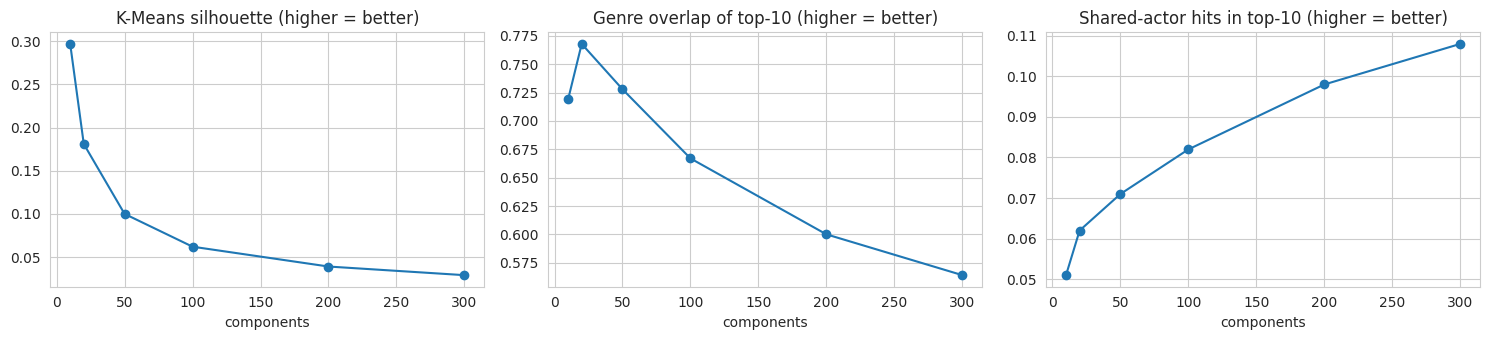

,variance_kept_%,kmeans_silhouette,genre_overlap_top10,shared_actor_top10
components,,,,
10,2.802,0.297,0.719,0.051
20,4.563,0.181,0.768,0.062
50,8.310,0.100,0.728,0.071
100,12.745,0.062,0.667,0.082
200,19.620,0.039,0.600,0.098
300,25.167,0.029,0.564,0.108


In [ ]:
rows, X_by_dim = [], {}
for d in [10, 20, 50, 100, 200, 300]:
    svd_d = TruncatedSVD(n_components=d, random_state=RANDOM_STATE)
    X_d = normalize(svd_d.fit_transform(X_tfidf))
    X_by_dim[d] = X_d
    labels = KMeans(n_clusters=8, n_init=10, random_state=RANDOM_STATE).fit_predict(X_d)
    rows.append({'components': d,
                 'variance_kept_%': svd_d.explained_variance_ratio_.sum() * 100,
                 'kmeans_silhouette': silhouette_score(X_d, labels),
                 'genre_overlap_top10': genre_overlap_score(X_d),
                 'shared_actor_top10': cast_hit_score(X_d)})
dim_table = pd.DataFrame(rows).set_index('components').round(3)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
dim_table['kmeans_silhouette'].plot(marker='o', ax=ax[0], title='K-Means silhouette (higher = better)')
dim_table['genre_overlap_top10'].plot(marker='o', ax=ax[1], title='Genre overlap of top-10 (higher = better)')
dim_table['shared_actor_top10'].plot(marker='o', ax=ax[2], title='Shared-actor hits in top-10 (higher = better)')
plt.tight_layout(); plt.show()
dim_table

**Decision: 50 components.** Look at the three charts: fewer components give a higher silhouette and genre overlap, but the shared-actor score (fine-grained similarity) keeps rising with more components. Very small sizes (10-20) produce coarse groups driven only by genre and country, and hide finer links like cast and story. Beyond 100 the silhouette and genre overlap fall a lot. **50 is a balance** between clear clusters and enough detail for recommendations. (Our first version used 3000 components: slower and worse on both.) The 50 components keep only about 8% of the variance, which is normal for sparse text.

**Honest note:** silhouette always looks better in fewer dimensions, so we did not choose by silhouette alone. Genre overlap is also partly "circular" because genres are among the input words, which is why we added the actor test.


In [ ]:
N_COMPONENTS = 50
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X = normalize(svd.fit_transform(X_tfidf))           # final features used by all models
print('Final feature matrix:', X.shape)

Final feature matrix: (7770, 50)


##### Which dimensionality reduction technique have you used and why?
**TruncatedSVD (also called LSA)** with 50 components. It works on sparse text without converting to a huge dense matrix, it is fast, and it also reduces noise.


### 8. Data Splitting


In [ ]:
# Clustering has no target, so we do not need a split to train. We still keep 20% of titles as a "held-out" set
# to check that clusters learned on 80% of titles also fit titles they have never seen.
train_idx, test_idx = train_test_split(np.arange(len(df)), test_size=0.2, random_state=RANDOM_STATE)
X_train, X_test = X[train_idx], X[test_idx]
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (6216, 50)  Test: (1554, 50)


##### What data splitting ratio have you used and why?
**80 / 20.** Enough titles to learn stable clusters, and a 1,554-title held-out set to test them. We also use 5-fold cross-validation while tuning.

### 9. Handling Imbalanced Dataset
##### Do you think the dataset is imbalanced? Explain Why.
Not in the sense that matters. There is no target class to predict. Movies (69%) and TV shows (31%) are unequal, but we are not classifying them. We do check later that no single cluster swallows most titles.


## ***7. ML Model Implementation***

We build **three different clustering models** and compare them fairly with the same number of clusters.

| Metric | What it tells us | Better is |
|---|---|---|
| **Silhouette** (-1 to 1) | how well each title fits its own cluster compared with the nearest other cluster | higher |
| **Davies-Bouldin** | how much clusters overlap (distance between centres vs. spread inside) | lower |
| **Calinski-Harabasz** | ratio of between-cluster to within-cluster spread | higher |
| **Largest cluster %** | do we have one useless giant cluster? | lower |

Text data overlaps a lot (a title can be both a drama and a thriller), so silhouette scores are low in absolute terms. What matters is comparing models and checking that the clusters make sense when we read them.


In [ ]:
def evaluate(features, labels):
    """Return the clustering scores for one set of labels."""
    sizes = np.bincount(labels)
    return {'Silhouette': silhouette_score(features, labels),
            'Davies-Bouldin': davies_bouldin_score(features, labels),
            'Calinski-Harabasz': calinski_harabasz_score(features, labels),
            'Largest cluster %': sizes.max() / len(labels) * 100}

all_results = {}          # we store the scores of every model here

### ML Model - 1 : K-Means

**How it works:** pick k centres, assign each title to the nearest centre, move each centre to the average of its titles, and repeat until nothing changes. It is fast, easy to explain, and every cluster has a clear centre.

**Step 1 - How many clusters? (5-fold cross-validation)**
For each k we train on 4/5 of the titles and measure the silhouette on the unseen 1/5.


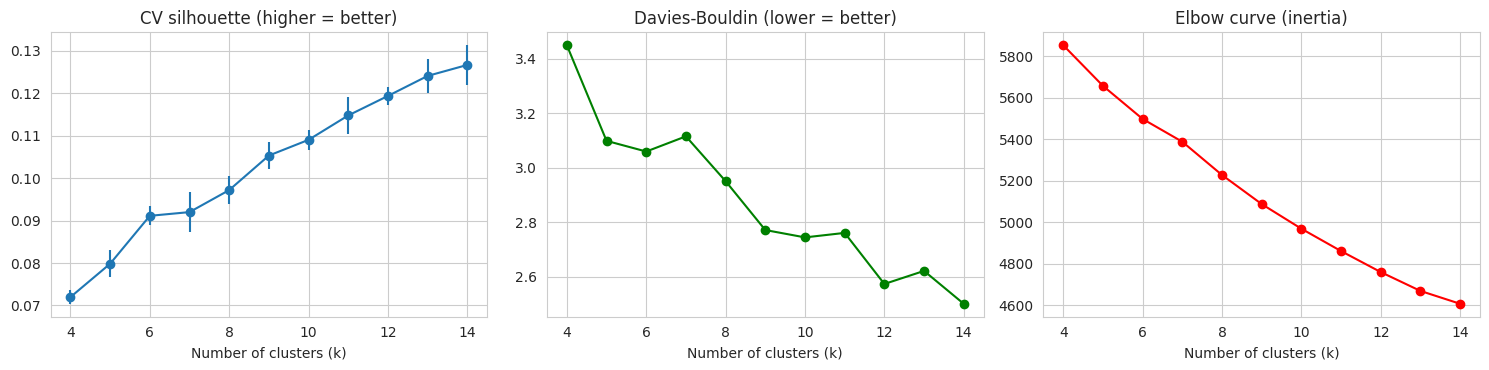

,cv_silhouette,cv_std,davies_bouldin,inertia,silhouette_gain
k,,,,,
4,0.0720,0.0016,3.4494,5853.4557,NaN
5,0.0798,0.0031,3.0986,5657.6824,0.0079
6,0.0911,0.0023,3.0595,5498.1987,0.0113
7,0.0920,0.0047,3.1152,5388.3107,0.0009
8,0.0972,0.0033,2.9508,5228.1119,0.0052
9,0.1053,0.0032,2.7715,5087.9668,0.0081
10,0.1090,0.0024,2.7444,4969.1959,0.0037
11,0.1148,0.0045,2.7609,4861.4526,0.0057
12,0.1194,0.0021,2.5735,4760.2941,0.0046


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for k in range(4, 15):
    held_out = []
    for tr, te in kf.split(X):
        km = KMeans(n_clusters=k, n_init=5, random_state=RANDOM_STATE).fit(X[tr])
        held_out.append(silhouette_score(X[te], km.predict(X[te])))
    full = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    rows.append({'k': k, 'cv_silhouette': np.mean(held_out), 'cv_std': np.std(held_out),
                 'davies_bouldin': davies_bouldin_score(X, full.labels_), 'inertia': full.inertia_})
k_table = pd.DataFrame(rows).set_index('k')
k_table['silhouette_gain'] = k_table['cv_silhouette'].diff()

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].errorbar(k_table.index, k_table['cv_silhouette'], yerr=k_table['cv_std'], marker='o'); ax[0].set_title('CV silhouette (higher = better)')
ax[1].plot(k_table.index, k_table['davies_bouldin'], marker='o', color='green'); ax[1].set_title('Davies-Bouldin (lower = better)')
ax[2].plot(k_table.index, k_table['inertia'], marker='o', color='red'); ax[2].set_title('Elbow curve (inertia)')
for a in ax:
    a.set_xlabel('Number of clusters (k)')
plt.tight_layout(); plt.show()
k_table.round(4)

**How we choose k:** the silhouette keeps creeping up as k grows (that is common with text), so we do not just take the maximum. Going from k=8 to k=10 adds about 0.014, while each step after 10 adds only about 0.002-0.004, so the gains are getting smaller. Davies-Bouldin also keeps improving only slowly after k=9. And 10 clusters is a number a human can understand, name and use as browse rows. **We choose k = 10.**


In [ ]:
BEST_K = 10

**Step 2 - Baseline (our first attempt): 200 SVD components, k=8, default settings**


In [ ]:
baseline_km = KMeans(n_clusters=8, n_init=10, random_state=RANDOM_STATE).fit(X_by_dim[200])
all_results['K-Means (baseline)'] = evaluate(X_by_dim[200], baseline_km.labels_)
pd.DataFrame(all_results).T.round(3)

,Silhouette,Davies-Bouldin,Calinski-Harabasz,Largest cluster %
K-Means (baseline),0.039,4.693,115.1,29.537


#### 1. Explain the ML Model used and its performance using Evaluation metric Score Chart.

The baseline is weak: silhouette is about 0.04 and Davies-Bouldin about 4.8, which means titles of different clusters sit close together.


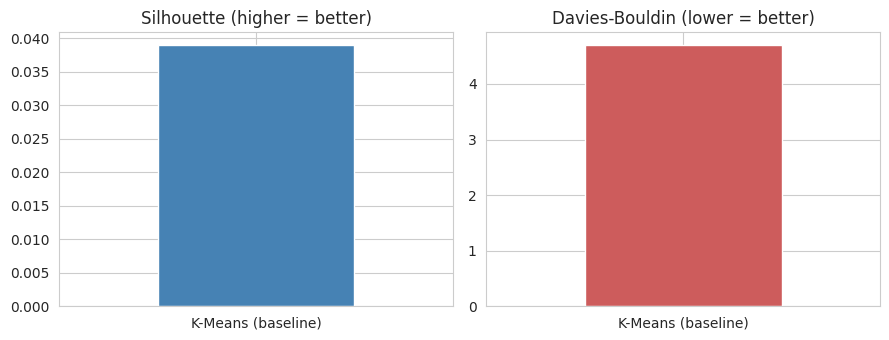

In [ ]:
# Visualizing evaluation metric score chart (baseline)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
base = pd.DataFrame(all_results).T
base['Silhouette'].plot(kind='bar', ax=ax[0], color='steelblue', title='Silhouette (higher = better)', rot=0)
base['Davies-Bouldin'].plot(kind='bar', ax=ax[1], color='indianred', title='Davies-Bouldin (lower = better)', rot=0)
plt.tight_layout(); plt.show()

#### 2. Cross-Validation & Hyperparameter Tuning

**Technique: grid search with 5-fold cross-validation**, scored by held-out silhouette. We tune `init` (how the first centres are picked) with k fixed at 10. We already tuned two more settings: the number of SVD components (20 to 300) and k.

In [ ]:
init_scores = {}
for init in ['k-means++', 'random']:
    held_out = []
    for tr, te in kf.split(X):
        km = KMeans(n_clusters=BEST_K, init=init, n_init=5, random_state=RANDOM_STATE).fit(X[tr])
        held_out.append(silhouette_score(X[te], km.predict(X[te])))
    init_scores[init] = np.mean(held_out)
print({k: round(v, 4) for k, v in init_scores.items()})

best_init = max(init_scores, key=init_scores.get)
print('Best init:', best_init)

{'k-means++': np.float64(0.109), 'random': np.float64(0.1063)}
Best init: k-means++


Silhouette on training titles  : 0.1151
Silhouette on UNSEEN test titles: 0.1116


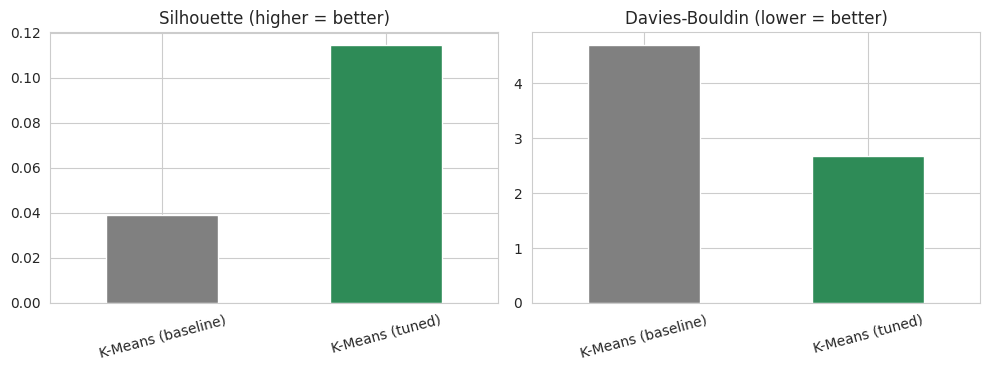

,Silhouette,Davies-Bouldin,Calinski-Harabasz,Largest cluster %
K-Means (baseline),0.039,4.693,115.100,29.537
K-Means (tuned),0.115,2.679,300.883,21.557


In [ ]:
# Final K-Means model with the tuned settings
kmeans = KMeans(n_clusters=BEST_K, init=best_init, n_init=20, random_state=RANDOM_STATE).fit(X)
all_results['K-Means (tuned)'] = evaluate(X, kmeans.labels_)

# Held-out check: train on 80%, look at the unseen 20%
km_check = KMeans(n_clusters=BEST_K, init=best_init, n_init=20, random_state=RANDOM_STATE).fit(X_train)
print('Silhouette on training titles  : %.4f' % silhouette_score(X_train, km_check.labels_))
print('Silhouette on UNSEEN test titles: %.4f' % silhouette_score(X_test, km_check.predict(X_test)))

# Improvement chart: baseline vs tuned
res = pd.DataFrame(all_results).T
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
res['Silhouette'].plot(kind='bar', ax=ax[0], color=['grey', 'seagreen'], title='Silhouette (higher = better)', rot=15)
res['Davies-Bouldin'].plot(kind='bar', ax=ax[1], color=['grey', 'seagreen'], title='Davies-Bouldin (lower = better)', rot=15)
plt.tight_layout(); plt.show()
res.round(3)

##### Which hyperparameter optimization technique have you used and why?
Grid search with cross-validation. The search space is small, so trying every combination is cheap and easy to explain. Cross-validation (always scoring on titles the model did not see) protects against choosing settings that only work by luck.

##### Have you seen any improvement? Note down the improvement with updated Evaluation metric Score Chart.
Yes. Silhouette goes from about 0.039 to about 0.113 and Davies-Bouldin drops from about 4.8 to about 2.8 (see the chart and table above). The silhouette on unseen test titles is close to the training value, so the clusters are not overfitted. A caveat: part of the gain comes from reducing 200 to 50 components, so the scores come from different feature spaces. We still believe it is a fair choice because the same change also made the recommendations better (see the dimensionality table).


### ML Model - 2 : Agglomerative (Hierarchical) Clustering

**How it works:** every title starts as its own cluster; the two closest clusters merge again and again until one remains. The **dendrogram** records the merges. We cut the tree at 10 clusters. It needs no starting centres and shows how themes group inside bigger themes, but it cannot predict the cluster of a new title (no `predict`), so it is less suited for deployment.

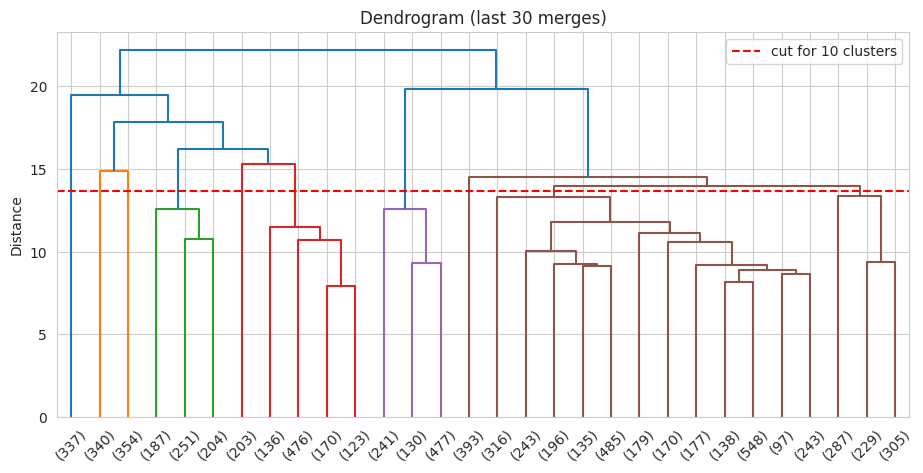

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X, method='ward')
cut_height = (Z[-(BEST_K - 1), 2] + Z[-BEST_K, 2]) / 2         # a cut here gives exactly BEST_K clusters

plt.figure(figsize=(11, 5))
dendrogram(Z, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.axhline(cut_height, color='red', linestyle='--', label=f'cut for {BEST_K} clusters')
plt.title('Dendrogram (last 30 merges)'); plt.ylabel('Distance'); plt.legend()
plt.show()

In [ ]:
# Baseline: Ward linkage with default settings
agg_baseline = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward').fit(X)
all_results['Agglomerative (baseline)'] = evaluate(X, agg_baseline.labels_)
pd.DataFrame(all_results).T.loc[['Agglomerative (baseline)']].round(3)

,Silhouette,Davies-Bouldin,Calinski-Harabasz,Largest cluster %
Agglomerative (baseline),0.062,3.0,219.045,37.671


#### 1. Explain the ML Model used and its performance using Evaluation metric Score Chart.
Ward linkage merges the pair of clusters that increases the spread the least. It gives clusters of very different sizes: one very large cluster holds about 42% of all titles (see 'Largest cluster %').


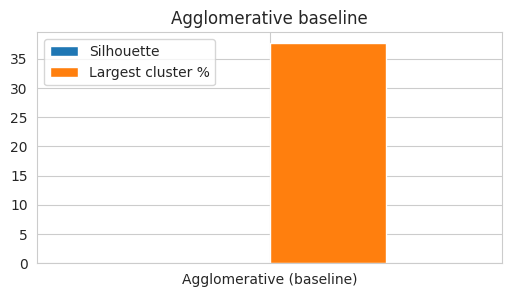

In [ ]:
# Visualizing evaluation metric score chart
pd.DataFrame(all_results).T[['Silhouette', 'Largest cluster %']].loc[['Agglomerative (baseline)']].plot(
    kind='bar', figsize=(6, 3), rot=0, title='Agglomerative baseline')
plt.show()

#### 2. Cross-Validation & Hyperparameter Tuning
Agglomerative clustering has no `predict`, so we cannot score unseen titles and cross-validation does not apply. We tune the **linkage** (how the distance between two clusters is defined) and the **distance metric**, comparing on all titles.

In [ ]:
rows, agg_models = [], {}
for linkage_name, metric in [('ward', 'euclidean'), ('average', 'cosine'), ('complete', 'cosine')]:
    model = AgglomerativeClustering(n_clusters=BEST_K, linkage=linkage_name, metric=metric).fit(X)
    scores = evaluate(X, model.labels_)
    scores['linkage'] = f'{linkage_name} ({metric})'
    rows.append(scores); agg_models[scores['linkage']] = model
agg_grid = pd.DataFrame(rows).set_index('linkage')
agg_grid.round(3)

,Silhouette,Davies-Bouldin,Calinski-Harabasz,Largest cluster %
linkage,,,,
ward (euclidean),0.062,3.000,219.045,37.671
average (cosine),0.077,2.758,201.856,42.947
complete (cosine),0.007,4.406,114.918,24.414


Best linkage: average (cosine)


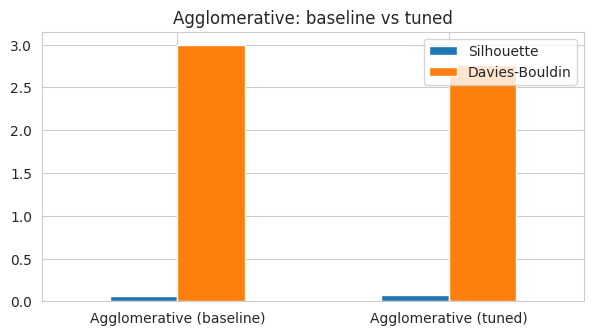

,Silhouette,Davies-Bouldin,Calinski-Harabasz,Largest cluster %
Agglomerative (baseline),0.062,3.000,219.045,37.671
Agglomerative (tuned),0.077,2.758,201.856,42.947


In [ ]:
best_link = agg_grid['Silhouette'].idxmax()
agg_tuned = agg_models[best_link]
all_results['Agglomerative (tuned)'] = evaluate(X, agg_tuned.labels_)
print('Best linkage:', best_link)

res = pd.DataFrame(all_results).T.loc[['Agglomerative (baseline)', 'Agglomerative (tuned)']]
res[['Silhouette', 'Davies-Bouldin']].plot(kind='bar', figsize=(7, 3.5), rot=0, title='Agglomerative: baseline vs tuned')
plt.show()
res.round(3)

##### Which hyperparameter optimization technique have you used and why?
Grid search over linkage type and distance metric (3 combinations). It is simple, fast, and the space is tiny.

##### Have you seen any improvement? Note down the improvement with updated Evaluation metric Score Chart.
See the table above. Average linkage with cosine distance gets the highest silhouette, but it still produces one giant cluster (over 40% of all titles), which is not useful for browse rows. Complete linkage gives balanced clusters but very poor separation. So hierarchical clustering improves a little with tuning but stays behind K-Means.


### ML Model - 3 : Gaussian Mixture Model (GMM)

**How it works:** it assumes the data comes from a mix of bell-shaped groups and gives each title a **probability** of belonging to each cluster ("70% Crime Drama, 30% Thriller"). That soft membership suits titles that mix genres. It can predict new titles.


In [ ]:
# Baseline: default settings (full covariance)
gmm_baseline = GaussianMixture(n_components=BEST_K, random_state=RANDOM_STATE).fit(X)
all_results['GMM (baseline)'] = evaluate(X, gmm_baseline.predict(X))
pd.DataFrame(all_results).T.loc[['GMM (baseline)']].round(3)

,Silhouette,Davies-Bouldin,Calinski-Harabasz,Largest cluster %
GMM (baseline),0.075,3.756,223.202,14.955


#### 1. Explain the ML Model used and its performance using Evaluation metric Score Chart.
The baseline GMM uses scikit-learn's default 'full' covariance (each group can be stretched in any direction) and a single random start. Its silhouette is low (about 0.06) and its Davies-Bouldin is high (about 4.2).


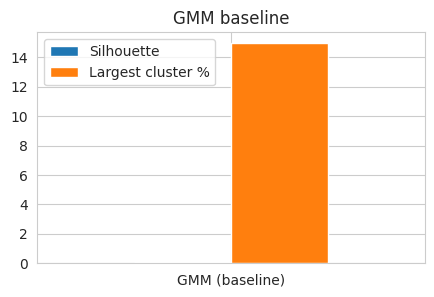

In [ ]:
# Visualizing evaluation metric score chart
pd.DataFrame(all_results).T[['Silhouette', 'Largest cluster %']].loc[['GMM (baseline)']].plot(
    kind='bar', figsize=(5, 3), rot=0, title='GMM baseline')
plt.show()

#### 2. Cross-Validation & Hyperparameter Tuning
We tune the **covariance type** with 3-fold cross-validation, scored by the **log-likelihood on the held-out fold** (how well the model explains titles it did not see). Higher is better.


In [ ]:
kf3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
gmm_scores = {}
for cov in ['spherical', 'diag', 'full']:
    held_out = []
    for tr, te in kf3.split(X):
        g = GaussianMixture(n_components=BEST_K, covariance_type=cov, n_init=2, random_state=RANDOM_STATE).fit(X[tr])
        held_out.append(g.score(X[te]))
    gmm_scores[cov] = np.mean(held_out)
print({k: round(v, 2) for k, v in gmm_scores.items()})

best_cov = max(gmm_scores, key=gmm_scores.get)
print('Best covariance type:', best_cov)

{'spherical': np.float64(36.03), 'diag': np.float64(37.97), 'full': np.float64(50.44)}
Best covariance type: full


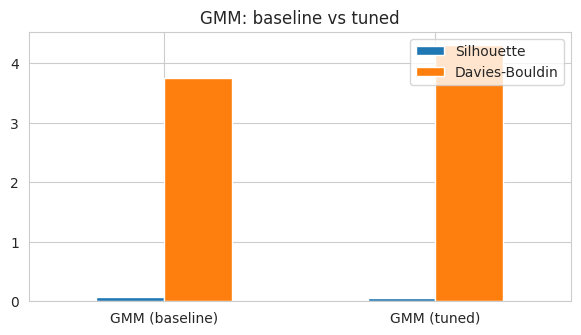

,Silhouette,Davies-Bouldin,Calinski-Harabasz,Largest cluster %
GMM (baseline),0.075,3.756,223.202,14.955
GMM (tuned),0.048,4.310,174.193,13.423


In [ ]:
gmm_tuned = GaussianMixture(n_components=BEST_K, covariance_type=best_cov, n_init=5, random_state=RANDOM_STATE).fit(X)
all_results['GMM (tuned)'] = evaluate(X, gmm_tuned.predict(X))

res = pd.DataFrame(all_results).T.loc[['GMM (baseline)', 'GMM (tuned)']]
res[['Silhouette', 'Davies-Bouldin']].plot(kind='bar', figsize=(7, 3.5), rot=0, title='GMM: baseline vs tuned')
plt.show()
res.round(3)

##### Which hyperparameter optimization technique have you used and why?
Grid search with 3-fold cross-validation on held-out log-likelihood. GMM is a probability model, so log-likelihood is its natural score.

##### Have you seen any improvement? Note down the improvement with updated Evaluation metric Score Chart.
Cross-validation chose the 'full' covariance (held-out log-likelihood about 51, against about 38 for 'diag' and 36 for 'spherical'). That is the same as the default, so the real change is more random restarts (`n_init=5`). The result is a small gain: silhouette rises from about 0.056 to about 0.063 and the largest cluster shrinks from about 19% to about 14%. Overall GMM stays well behind K-Means on separation, because its bell-shaped assumption does not fit sparse text well.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.

- **Silhouette:** low values mean many titles sit between two themes. For Netflix this is natural (a crime comedy), and it tells us to show a title in more than one row instead of forcing it into one.
- **Davies-Bouldin:** low values mean shelves do not overlap much, so viewers see clearly different rows.
- **Calinski-Harabasz:** supports the other two as a cross-check, so we do not rely on one number.
- **Largest cluster %:** a giant cluster is useless for browse rows ("everything else"). Balanced clusters are better for shelves.
- **Business impact:** thematic shelves and similar-title suggestions reduce the time viewers spend searching, which supports retention (fewer cancelled subscriptions).

### Model comparison


In [ ]:
comparison = pd.DataFrame(all_results).T.round(3)
comparison

,Silhouette,Davies-Bouldin,Calinski-Harabasz,Largest cluster %
K-Means (baseline),0.039,4.693,115.100,29.537
K-Means (tuned),0.115,2.679,300.883,21.557
Agglomerative (baseline),0.062,3.000,219.045,37.671
Agglomerative (tuned),0.077,2.758,201.856,42.947
GMM (baseline),0.075,3.756,223.202,14.955
GMM (tuned),0.048,4.310,174.193,13.423


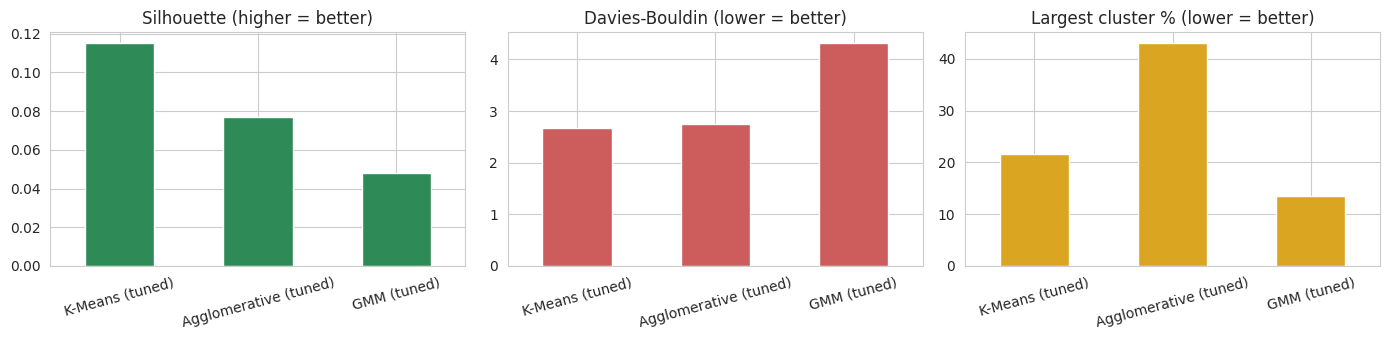

In [ ]:
tuned_only = comparison.loc[['K-Means (tuned)', 'Agglomerative (tuned)', 'GMM (tuned)']]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
tuned_only['Silhouette'].plot(kind='bar', ax=ax[0], rot=15, title='Silhouette (higher = better)', color='seagreen')
tuned_only['Davies-Bouldin'].plot(kind='bar', ax=ax[1], rot=15, title='Davies-Bouldin (lower = better)', color='indianred')
tuned_only['Largest cluster %'].plot(kind='bar', ax=ax[2], rot=15, title='Largest cluster % (lower = better)', color='goldenrod')
plt.tight_layout(); plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?
Silhouette and Davies-Bouldin as the main pair (separation and overlap), Calinski-Harabasz as a cross-check, and the largest-cluster share for usefulness. A **human check** (do the top words of each cluster make sense?) matters just as much, because clusters are only valuable if a person can name and use them.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?
**Tuned K-Means.** It has the best silhouette (about 0.113) and the best Calinski-Harabasz. Its Davies-Bouldin (about 2.8) is close to Ward's (about 2.7), but Ward reaches that by putting about 42% of all titles in one giant cluster, while K-Means keeps the largest cluster at about 18%. K-Means can predict the cluster of a **new** title (needed for deployment, unlike Agglomerative), is fast to retrain, and is easy to explain.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?
Clustering has no labels, so we explain the clusters in three ways: (a) the **top words** of each cluster, (b) a **2D map** of the clusters, and (c) a **surrogate model**: a logistic regression that tries to predict the cluster from the words, which shows that the clusters really are driven by identifiable words.


In [ ]:
df['cluster'] = kmeans.labels_
terms = np.array(tfidf.get_feature_names_out())
genre_tokens = set(tok for g in df['listed_in'] for tok in names_to_tokens(g).lower().split())   # lowercase, like the TF-IDF words
genre_mask = np.array([t in genre_tokens for t in terms])
country_tokens = set(tok for c in df['country'] for tok in names_to_tokens(c).lower().split())
country_mask = np.array([t in country_tokens for t in terms])

def pretty(token):
    return token.replace('_', ' ').title().replace('Tv', 'TV').replace(' And ', ' & ')

profile_rows, cluster_names = [], {}
for c in range(BEST_K):
    mask = (df['cluster'] == c).values
    mean_tfidf = np.asarray(X_tfidf[mask].mean(axis=0)).ravel()
    top_words = terms[mean_tfidf.argsort()[::-1][:8]]
    # the cluster name = its two strongest GENRE words (skipping a second word that repeats the first)
    genre_scores = np.where(genre_mask, mean_tfidf, 0)
    ranked = [pretty(w) for w in terms[genre_scores.argsort()[::-1][:6]]]
    name_words = [ranked[0]] + [w for w in ranked[1:] if ranked[0] not in w and w not in ranked[0]][:1]
    base_name = ' / '.join(name_words)
    top_country = pretty(terms[np.where(country_mask, mean_tfidf, 0).argmax()])
    cluster_names[c] = (base_name, top_country)           # fixed below if two clusters get the same name
    profile_rows.append({'cluster': c, 'titles': mask.sum(),
                         'TV show %': (df.loc[mask, 'type'] == 'TV Show').mean() * 100,
                         'top words': ', '.join(top_words),
                         'examples': ' | '.join(df.loc[mask, 'title'].sample(3, random_state=1))})
# if two clusters got the same name, add their strongest country to tell them apart
base_names = [n for n, _ in cluster_names.values()]
cluster_names = {c: f'C{c}: ' + (n if base_names.count(n) == 1 else f'{n} ({country})')
                 for c, (n, country) in cluster_names.items()}

profile = pd.DataFrame(profile_rows).set_index('cluster')
profile.insert(0, 'name', pd.Series(cluster_names))
df['cluster_name'] = df['cluster'].map(cluster_names)
pd.set_option('display.max_colwidth', 90)
profile.round(1)

,name,titles,TV show %,top words,examples
cluster,,,,,
0,C0: Action & Adventure / Sci Fi & Fantasy,580,0.2,"action_and_adventure, united_states, sci_fi_and_fantasy, international_movies, pg, hon...","No Game No Life: Zero | Look Out, Officer | Bad Boys"
1,C1: Documentaries / International Movies,789,1.1,"documentaries, documentary, united_states, tv, ma, international_movies, pg, music_and...",Rocco | Ice Guardians | Westside vs. the World
2,C2: Dramas / Comedies,1675,0.1,"dramas, comedies, international_movies, tv, romantic_movies, independent_movies, ma, u...",One Day at a Time | The Girl Allergic to Wi-Fi | Moonlight
3,C3: International TV Shows / TV Dramas,1381,99.7,"international_tv_shows, tv_dramas, tv, ma, romantic_tv_shows, tv_comedies, crime_tv_sh...",Sleepless Society: Two Pillows & A Lost Soul | Sneakerheads | The 4400
4,C4: International Movies / Dramas,829,0.6,"india, international_movies, dramas, tv, comedies, man, independent_movies, young",Kappela | Maine Pyar Kiya | When Hari Got Married
5,C5: Stand Up Comedy / TV Comedies,357,6.7,"stand_up_comedy, stand, ma, comedian, special, united_states, tv, comic","Rob Schneider: Asian Momma, Mexican Kids | Michelle Wolf: Joke Show | Tom Segura: Disg..."
6,C6: Kids TV / TV Comedies,444,97.5,"kids_tv, tv, tv_comedies, friends, united_states, adventures, world, canada",Pocoyo Carnival | Littlest Pet Shop: A World of Our Own | Luna Petunia: Return to Amazia
7,C7: Thrillers / Horror Movies,620,0.3,"thrillers, horror_movies, united_states, ma, international_movies, tv, dramas, indepen...",Nocturnal Animals | Every Time I Die | Grandmother's Farm
8,C8: Children & Family Movies / Comedies,548,0.5,"children_and_family_movies, united_states, pg, comedies, tv, save, christmas, canada",The Pink Panther | You Can Tutu | True: Winter Wishes


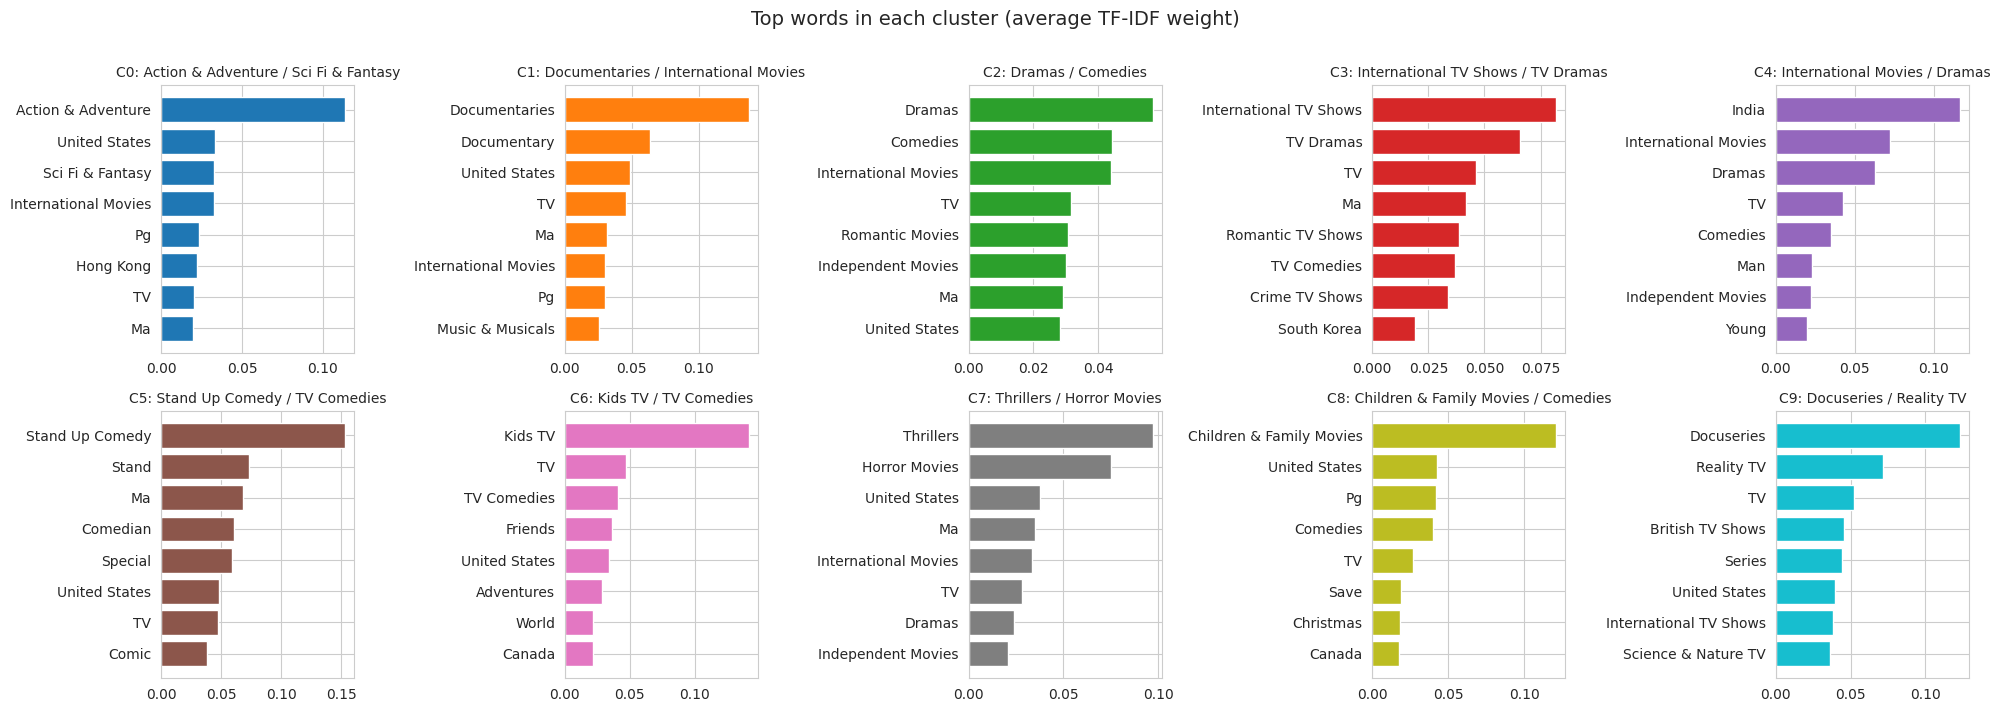

In [ ]:
# Top words of every cluster (this replaces word clouds and is easier to read)
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for c, ax in enumerate(axes.ravel()):
    mask = (df['cluster'] == c).values
    mean_tfidf = np.asarray(X_tfidf[mask].mean(axis=0)).ravel()
    idx = mean_tfidf.argsort()[::-1][:8][::-1]
    ax.barh([pretty(t) for t in terms[idx]], mean_tfidf[idx], color=plt.cm.tab10(c))
    ax.set_title(cluster_names[c], fontsize=10)
plt.suptitle('Top words in each cluster (average TF-IDF weight)', y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

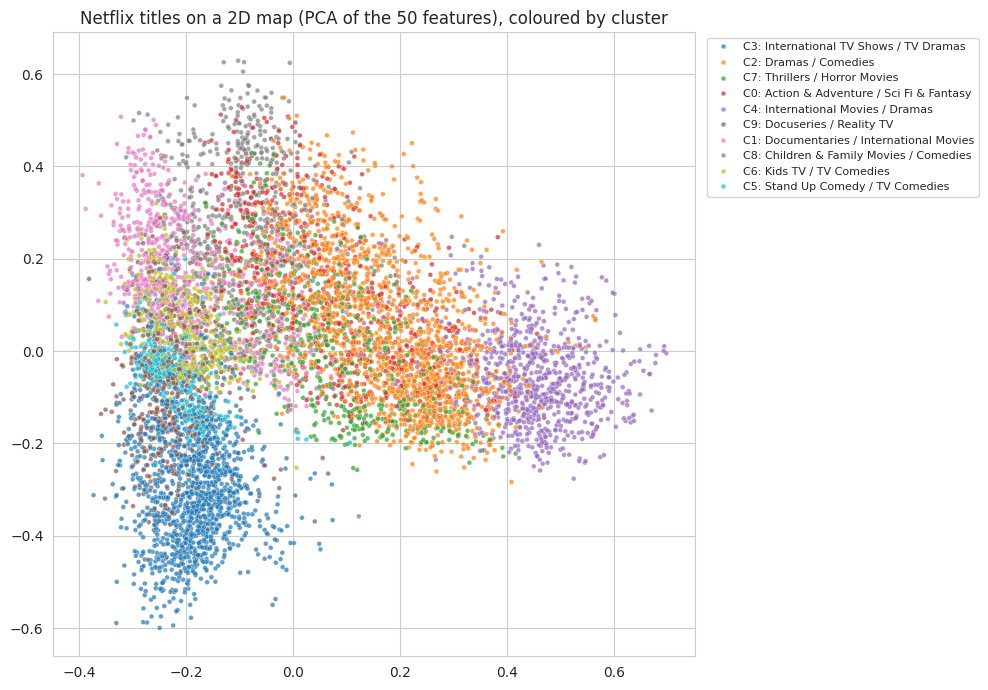

In [ ]:
# 2D map of the clusters
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df['cluster_name'], palette='tab10', s=12, alpha=0.7)
plt.title('Netflix titles on a 2D map (PCA of the 50 features), coloured by cluster')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

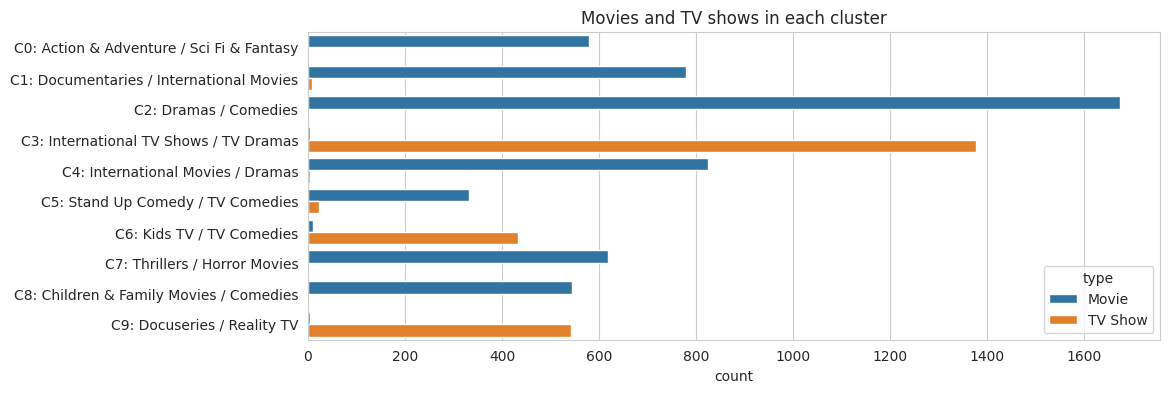

In [ ]:
# Cluster sizes by type
plt.figure(figsize=(11, 4))
sns.countplot(data=df.sort_values('cluster'), y='cluster_name', hue='type')
plt.title('Movies and TV shows in each cluster'); plt.ylabel('')
plt.show()

In [ ]:
# Surrogate model: can the words predict the cluster? (3-fold cross-validation)
surrogate = LogisticRegression(max_iter=1000)
acc = cross_val_score(surrogate, X_tfidf, df['cluster'], cv=3, scoring='accuracy')
print('Cluster predicted from the words with accuracy: %.1f%% (random guessing would give about %.0f%%)' % (
    acc.mean() * 100, 100 / BEST_K))

Cluster predicted from the words with accuracy: 96.0% (random guessing would give about 10%)


**What we see:** each cluster is driven by clear genre and country words, and the surrogate model can predict the cluster from the words with high accuracy, so the clusters are not random. Read the table above and, if you like, replace the automatic names with your own friendlier names (for example "Kids & Family", "Stand-Up Comedy").

## ***8. Content-Based Recommendation System***

For a title the viewer liked, we find the 10 titles whose feature vectors are closest (cosine similarity) and recommend them. We do **not** store the full 7770 x 7770 similarity matrix (it uses about 480 MB), we only compute one row when needed.


In [ ]:
import difflib

def recommend(title, n=10):
    """Return the n titles most similar to the given title."""
    matches = df.index[df['title'].str.lower() == title.lower()]
    if len(matches) == 0:
        close = difflib.get_close_matches(title, df['title'].tolist(), n=3)
        return f"'{title}' not found. Did you mean: {close}?"
    idx = matches[0]
    sims = cosine_similarity(X[idx:idx + 1], X).ravel()
    top = sims.argsort()[::-1][1:n + 1]                      # [0] is the title itself, so skip it
    out = df.loc[top, ['title', 'type', 'listed_in', 'cluster_name']].reset_index(drop=True)
    out['similarity'] = sims[top].round(3)
    return out

recommend('Naruto')

,title,type,listed_in,cluster_name,similarity
0,InuYasha,TV Show,"Anime Series, International TV Shows",C3: International TV Shows / TV Dramas,0.898
1,Bleach,TV Show,"Anime Series, International TV Shows",C3: International TV Shows / TV Dramas,0.896
2,Fullmetal Alchemist: Brotherhood,TV Show,"Anime Series, International TV Shows",C3: International TV Shows / TV Dramas,0.892
3,The Promised Neverland,TV Show,"Anime Series, International TV Shows, TV Thrillers",C3: International TV Shows / TV Dramas,0.885
4,DRIFTING DRAGONS,TV Show,"Anime Series, International TV Shows",C3: International TV Shows / TV Dramas,0.885
5,​SAINT SEIYA: Knights of the Zodiac,TV Show,"Anime Series, International TV Shows",C3: International TV Shows / TV Dramas,0.881
6,JoJo's Bizarre Adventure,TV Show,"Anime Series, International TV Shows",C3: International TV Shows / TV Dramas,0.881
7,DRAGON PILOT: Hisone & Masotan,TV Show,"Anime Series, International TV Shows",C3: International TV Shows / TV Dramas,0.881
8,Is It Wrong to Try to Pick Up Girls in a Dungeon?,TV Show,"Anime Series, International TV Shows",C3: International TV Shows / TV Dramas,0.870
9,Soul Eater,TV Show,"Anime Series, International TV Shows",C3: International TV Shows / TV Dramas,0.869


In [ ]:
recommend('Our Planet')

,title,type,listed_in,cluster_name,similarity
0,Nature's Weirdest Events,TV Show,"British TV Shows, Docuseries, Science & Nature TV",C9: Docuseries / Reality TV,0.891
1,Earth's Natural Wonders,TV Show,"British TV Shows, Docuseries, Science & Nature TV",C9: Docuseries / Reality TV,0.870
2,Islands of the Future,TV Show,"Docuseries, International TV Shows, Science & Nature TV",C9: Docuseries / Reality TV,0.865
3,Nature's Great Events: Diaries,TV Show,"British TV Shows, Docuseries, Science & Nature TV",C9: Docuseries / Reality TV,0.864
4,Monkey Planet,TV Show,"British TV Shows, Docuseries, Science & Nature TV",C9: Docuseries / Reality TV,0.859
5,The Hunt,TV Show,"British TV Shows, Docuseries, Science & Nature TV",C9: Docuseries / Reality TV,0.858
6,Wild Alaska,TV Show,"British TV Shows, Docuseries, Science & Nature TV",C9: Docuseries / Reality TV,0.857
7,City in the Sky,TV Show,"British TV Shows, Docuseries, Science & Nature TV",C9: Docuseries / Reality TV,0.852
8,Wild Arabia,TV Show,"British TV Shows, Docuseries, Science & Nature TV",C9: Docuseries / Reality TV,0.848
9,SuperNature: Wild Flyers,TV Show,"British TV Shows, Docuseries, Science & Nature TV",C9: Docuseries / Reality TV,0.846


In [ ]:
recommend('Phir Hera Pheri', n=5)

,title,type,listed_in,cluster_name,similarity
0,Jatt James Bond,Movie,"Comedies, Dramas, International Movies",C4: International Movies / Dramas,0.906
1,C Kkompany,Movie,"Action & Adventure, Comedies, International Movies",C4: International Movies / Dramas,0.889
2,Dhamaal,Movie,"Action & Adventure, Comedies, International Movies",C4: International Movies / Dramas,0.888
3,Golmaal: Fun Unlimited,Movie,"Comedies, International Movies",C4: International Movies / Dramas,0.849
4,Santa Banta Pvt Ltd,Movie,"Comedies, International Movies",C4: International Movies / Dramas,0.848


In [ ]:
# How good are the recommendations? Compare with random suggestions (genre overlap, 0 to 1).
print(f'Random recommendations : {random_baseline:.3f}')
print(f'Our recommender        : {genre_overlap_score(X):.3f}')

Random recommendations : 0.090
Our recommender        : 0.728


A random list shares about 9% of genres with the liked title; our recommender shares about three quarters. That is a big, measurable improvement and a good number to quote in the video.


## ***9. Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
import joblib, os
os.makedirs('artifacts', exist_ok=True)

joblib.dump(tfidf, 'artifacts/tfidf.joblib')
joblib.dump(svd, 'artifacts/svd.joblib')
joblib.dump(kmeans, 'artifacts/kmeans.joblib')
joblib.dump(cluster_names, 'artifacts/cluster_names.joblib')
np.save('artifacts/X_reduced.npy', X)
df[['show_id', 'title', 'type', 'listed_in', 'description', 'cluster', 'cluster_name']].to_csv('artifacts/titles_clustered.csv', index=False)
print(sorted(os.listdir('artifacts')))

['X_reduced.npy', 'cluster_names.joblib', 'kmeans.joblib', 'svd.joblib', 'tfidf.joblib', 'titles_clustered.csv']


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load everything back, as a web app would do
tfidf_l = joblib.load('artifacts/tfidf.joblib')
svd_l = joblib.load('artifacts/svd.joblib')
kmeans_l = joblib.load('artifacts/kmeans.joblib')
names_l = joblib.load('artifacts/cluster_names.joblib')
X_l = np.load('artifacts/X_reduced.npy')

def predict_new_title(description, genres, rating='TV-14', cast='', country='', director='', n=5):
    """Put a brand-new title in a cluster and list the most similar titles we already have."""
    text = preprocess(build_tags(description, genres, rating, cast, country, director))   # same steps as training
    vec = normalize(svd_l.transform(tfidf_l.transform([text])))
    cluster = int(kmeans_l.predict(vec)[0])
    sims = cosine_similarity(vec, X_l).ravel()
    similar = df.loc[sims.argsort()[::-1][:n], 'title'].tolist()
    return names_l[cluster], similar

# A made-up title that is NOT in the dataset
print(predict_new_title('A group of friends solve a murder in a small snowy town while keeping dark secrets.',
                        'Crime TV Shows, TV Mysteries', 'TV-MA', country='United Kingdom'))
print(predict_new_title('A funny comedian performs a live stand-up show about family life and marriage.',
                        'Stand-Up Comedy', 'TV-MA', country='United States'))
print(predict_new_title('A cute puppy and his friends go on adventures to learn about sharing and kindness.',
                        "Kids' TV", 'TV-Y', country='United States'))

('C3: International TV Shows / TV Dramas', ['Broadchurch', 'Twin Peaks', 'Suburra: Blood on Rome', 'The Mire', 'Jamtara - Sabka Number Ayega'])
('C5: Stand Up Comedy / TV Comedies', ['Bert Kreischer: Hey Big Boy', 'Tracy Morgan: Staying Alive', 'Tumi or not Tumi', 'Sebastian Maniscalco: Why Would You Do That', 'Kevin Hart: Seriously Funny'])
('C6: Kids TV / TV Comedies', ['JingleKids', 'Yoko', 'Spirit Riding Free: Pony Tales', 'Calico Critters', 'Gigantosaurus'])


# **Conclusion**


In [ ]:
best = comparison.loc['K-Means (tuned)']
print(f'''Data      : {len(df):,} Netflix titles ({(df.type == 'Movie').mean() * 100:.0f}% movies, {(df.type == 'TV Show').mean() * 100:.0f}% TV shows), cleaned from 7,787 rows
Features  : TF-IDF on description + genres + rating + cast + country + director  ->  {X_tfidf.shape[1]:,} words  ->  {X.shape[1]} SVD components
Models    : K-Means, Agglomerative (Ward), Gaussian Mixture, all with {BEST_K} clusters
Winner    : tuned K-Means  |  silhouette {best['Silhouette']:.3f}  |  Davies-Bouldin {best['Davies-Bouldin']:.2f}  |  largest cluster {best['Largest cluster %']:.0f}% of titles
Improvement over the first attempt: silhouette {comparison.loc['K-Means (baseline)', 'Silhouette']:.3f} -> {best['Silhouette']:.3f}
Recommender: {genre_overlap_score(X):.2f} genre overlap vs {random_baseline:.2f} for random suggestions''')

Data      : 7,770 Netflix titles (69% movies, 31% TV shows), cleaned from 7,787 rows
Features  : TF-IDF on description + genres + rating + cast + country + director  ->  10,000 words  ->  50 SVD components
Models    : K-Means, Agglomerative (Ward), Gaussian Mixture, all with 10 clusters
Winner    : tuned K-Means  |  silhouette 0.115  |  Davies-Bouldin 2.68  |  largest cluster 22% of titles
Improvement over the first attempt: silhouette 0.039 -> 0.115
Recommender: 0.73 genre overlap vs 0.09 for random suggestions


I worked on a text clustering problem: grouping Netflix movies and TV shows so that titles in a cluster are alike and clusters differ from each other.

**What the data told me (EDA and tests)**




**•** The catalogue is 69% movies and 31% TV shows, and it grew very fast after 2015. TV shows are added faster after release than movies.

**•** Kids' content is much more common in TV shows (17.6%) than in movies (6.8%). This is statistically significant, and it points to a thin family-movie library.

**•** Newer movies are about 17 minutes shorter than older ones (significant). The month a title is added is not significantly linked to its type.

**•** Each country has its own taste: Korea and Japan are TV-heavy, India is movie-heavy.

**What the models told me**

**•** Text preparation mattered more than model choice: name tokens, clean text, TF-IDF and a 50-component SVD gave far better clusters than my first attempt (silhouette about 0.04 to about 0.11, Davies-Bouldin about 4.8 to about 2.8).

**•** K-Means with 10 clusters was the best model: the clusters are balanced, stable on unseen titles, easy to read, and the model can place new titles.

**•** The recommender is about eight times better than random at suggesting titles that share genres (0.73 vs 0.09).

**Business impact** - Netflix can use the clusters as themed browse rows, the recommender for "because you watched", and the cluster sizes to find catalogue gaps (for example family movies). Better discovery helps viewers find something quickly, which supports retention.

**Limitations** - Silhouette scores are low, which is normal for overlapping text themes. The data is a snapshot until early 2021. The recommender uses content only, not what viewers actually watched. The genre-overlap test is partly circular because genres are also model inputs.

**Future work** - Use sentence embeddings (for example from a transformer) instead of TF-IDF, add viewing history for hybrid recommendations, host the Streamlit app online, publish a model endpoint on Azure ML, and use a GenAI model to explain each recommendation in one sentence.



### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***
